# Mean signal and per-trial spike correlation in simultaneously recorded selective pairs

## Introduction

A single neuron's firing rate says what that neuron encodes. It says nothing
about whether neurons act together — and coordinated activity between neurons
carries information that neither carries alone, gates what downstream targets
receive, and changes with behavioural state even when firing rates do not.

Two neurons recorded at the same time can be related in two distinct ways, and
conflating them is the standard error in this literature. This chapter keeps them
apart by naming each after the operation that defines it.

**Mean signal correlation** is similarity of *tuning*. Each neuron's fixations are
averaged into a mean rate timeline first, and the two timelines are correlated. If
two neurons both respond to fixation onset with the same time course, their
averages resemble each other. This is a statement about what the two neurons
encode, and it survives averaging: it is visible in the mean response and requires
no simultaneous recording in principle.

**Per-trial spike correlation** is co-firing *within a fixation*. The two spike
trains are correlated inside each fixation first, and the correlograms are
averaged afterwards. If one neuron's spikes fall at a reliable delay from the
other's, beyond what their average rate profiles predict, the two are coupled in
time. This requires simultaneous recording by definition, and averaging destroys
it.

The names differ in one word — *mean* against *per-trial* — because the measures
differ in one step: whether the fixations are averaged before or after
correlating.

### A note on the second name

The per-trial measure is conventionally called *noise correlation*, and that name
is avoided here deliberately. Classical noise correlation is a single number per
pair: the Pearson correlation, across trials, of the two neurons' spike **counts**
in a window, after each neuron's condition mean has been subtracted. What is
computed here is a full cross-correlogram of the two spike trains **within each
fixation**, averaged across fixations afterwards. The two differ in what they can
see and in what scale they live on:

| | classical noise correlation | per-trial spike correlation (here) |
|---|---|---|
| unit of observation | one spike count per trial | one 1 ms spike train per trial |
| resolves timing | no — a window is integrated away | yes — a value at every lag |
| range | [−1, 1], normalised | unnormalised counts of spike pairs |
| what a null must destroy | trial-to-trial count covariation | fine temporal alignment |

Reporting the second under the first's name would invite comparing magnitudes
with a literature that measured something else. Everywhere below, *trial* means
one fixation.

### Why the distinction matters

The two measures are formally independent. Two neurons can have identical mean
responses and be statistically independent trial to trial; two neurons with
unrelated tuning can co-fire tightly through shared input. Which of the two a
behavioural variable modulates is therefore a substantive question, not a
technicality — modulating shared tuning means the population's *representation*
changes, while modulating co-firing means its *correlation structure* changes, and
these have opposite consequences for how much information the population carries.

This chapter asks which of the two, if either, distinguishes **interactive-face**
fixations from non-interactive-face and object fixations, in each of four
regions — BLA, ACCg, dmPFC and OFC — and across the region pairs the recordings
support.

### What is asked

1. Is there mean signal correlation between simultaneously recorded selective
   pairs, beyond what any two units of the same region show?
2. Does it depend on the fixation condition?
3. Is there per-trial spike correlation beyond what each unit's own
   fixation-locked rate profile predicts?
4. Does *that* depend on the fixation condition?
5. Are the two related — do pairs with shared tuning also co-fire?
6. Does any of this extend across regions?

## Methods

### Recordings, units and pairs

Single units were recorded simultaneously from BLA, ACCg, dmPFC and OFC while
two macaques viewed each other and non-social objects. Analysis is restricted to
**selective units**: a unit is selective when at least one of the three pairwise
fixation-type contrasts is significant for it in the single-unit analysis after
multiple-comparison correction (`three_condition_core` family,
`is_selective_unit_corrected`, which is itself an *any* over those contrasts).
Two justifications: a unit with no reliable fixation response contributes a mean
timeline that is mostly estimation noise, and correlating noise with noise adds
variance and nothing else; and the question *do units that respond to fixation
condition share response structure* presupposes units that respond.

A **pair** is two units recorded in the same session, and a pair is analysed only
when **both** its units are selective. Both measures are defined on exactly the
same pairs, so they can be compared pair for pair.

Two consequences of counting pairs are worth stating before any number below is
read. First, the inclusion rule applies twice, so it costs roughly its own square:
BLA has 53% of its units selective and keeps 38% of its pairs, and across all
groups between a fifth and two fifths of recorded pairs survive (Figures 2 and 6).
Second, pair counts grow with the square of the simultaneously recorded units, so
a session with 20 units contributes 190 within-region pairs and a session with 5
contributes 10. A minority of dense sessions therefore supplies most of the pairs,
which is why the per-session distribution below is given as a median and a maximum
rather than a mean, and why the pairs are not independent observations.

### Fixation conditions

Three conditions throughout, matching the single-unit and population analyses so
results can be joined without translation:

- **interactive face** — face fixations during interactive periods
- **non-interactive face** — face fixations outside them
- **object** — object fixations, pooled across interactive state

### Analysis window

All correlations use spikes within $[-500, +500]$ ms of fixation onset. The
per-trial measure uses 1 ms bins, **unsmoothed** ($N = 1000$ bins); the mean signal
measure uses the 10 ms binned rates ($M = 100$ bins) produced by the same
extraction, so the fixations, units and trials are identical to those in every
other chapter. Smoothing before cross-correlation blurs exactly the fine timing
the per-trial measure exists to detect.

The window is not widened. 95% of $\pm 5$ s surrounds of an analysed fixation
contain at least one *other* analysed fixation (median 5), so data outside the
window is not neutral baseline and a shifted-window null would compare against a
different behavioural condition rather than against nothing.

---

### Per-trial spike correlation

Write $x_i^{(t)} \in \{0,1,2,\dots\}^N$ and $x_j^{(t)}$ for the 1 ms binned spike
trains of units $i$ and $j$ on fixation $t$, with $t = 1,\dots,T_c$ the fixations
of condition $c$.

**The statistic.** The **linear** cross-correlation of one fixation's two trains,

$$
r_{ij}^{(t)}(\ell) \;=\; \sum_{n} x_i^{(t)}[n]\, x_j^{(t)}[n+\ell],
\qquad \ell = -(N-1),\dots,N-1 ,
$$

with terms outside $[1, N]$ absent. At lag $\ell$ only the $N - |\ell|$ genuinely
overlapping bins contribute, so no spike is ever paired with one a full window
away. In words, $r_{ij}^{(t)}(\ell)$ counts the spike pairs separated by exactly
$\ell$ ms within that fixation.

It is evaluated by zero-padding both trains to length $M \ge 2N-1$ and using the
transform,

$$
r_{ij}^{(t)} \;=\; \mathcal{F}^{-1}\!\left\{\overline{\mathcal{F}(x_i^{(t)})}\;\cdot\;\mathcal{F}(x_j^{(t)})\right\},
$$

which is exact, not an approximation. **The padding is what makes this linear.**
An unpadded transform returns the *circular* correlation
$\sum_n x_i[n]\,x_j[(n+\ell) \bmod N]$, which pairs a spike at $-500$ ms with one
at $+500$ ms and reports the pair at a short lag. The three are related exactly by

$$
r^{\text{circ}}(\ell) \;=\; r^{\text{lin}}(\ell) + r^{\text{lin}}(\ell - N) + r^{\text{lin}}(\ell + N),
$$

so the difference is aliasing, not truncation. This analysis uses the linear form
throughout, matching `scipy.signal.correlate(..., mode="full")` and the
behavioural cross-correlations elsewhere in this thesis.

Averaging over the fixations of a condition gives the pair's observed correlogram:

$$
R_{ij}^{c}(\ell) \;=\; \frac{1}{T_c}\sum_{t=1}^{T_c} r_{ij}^{(t)}(\ell).
$$

**The null: circular shift.** For draw $d = 1,\dots,D$ with $D = 50$, every
fixation independently receives its own rotation $s^{(t,d)}$ drawn uniformly from
the offsets with $|s| \ge 50$ ms:

$$
\tilde{x}_j^{(t,d)}[n] \;=\; x_j^{(t)}\!\left[(n - s^{(t,d)}) \bmod N\right],
\qquad
R_{ij}^{c,d}(\ell) \;=\; \frac{1}{T_c}\sum_{t} \big(x_i^{(t)} \star \tilde{x}_j^{(t,d)}\big)(\ell),
$$

and the null is summarised by its mean and spread across draws:

$$
\mu_{ij}^{c}(\ell) = \frac{1}{D}\sum_{d} R_{ij}^{c,d}(\ell),
\qquad
\sigma_{ij}^{c}(\ell) = \operatorname{sd}_{d}\big[R_{ij}^{c,d}(\ell)\big].
$$

The rotation is applied **within each fixation**, which is the whole point: every
fixation keeps its own spike count and its own slow envelope, so two neurons
whose excitability merely rises and falls together across fixations produce no
excess against this null. Only fine temporal alignment is destroyed. The $50$ ms
floor stops a rotation shorter than the coordination timescale from leaving the
effect partly intact.

**Excess and z.** Everything reported is the null-corrected quantity

$$
E_{ij}^{c}(\ell) \;=\; R_{ij}^{c}(\ell) - \mu_{ij}^{c}(\ell),
\qquad
z_{ij}^{c}(\ell) \;=\; \frac{E_{ij}^{c}(\ell)}{\sigma_{ij}^{c}(\ell)} .
$$

The linear correlation tapers — fewer bins contribute as $|\ell|$ grows — but both
the observed value and the null carry the identical taper, so it cancels in
$E$ and in $z$.

**Scalar summaries.** A correlogram is reduced to one number by averaging over a
lag window of half-width $W$ — the excess and the $z$ trace each in their own
right, the average taken over lags rather than the ratio of two averages:

$$
\bar{E}_{ij}^{c}(W) = \frac{1}{|\mathcal{L}_W|} \sum_{\ell \in \mathcal{L}_W} E_{ij}^{c}(\ell),
\qquad
\bar{z}_{ij}^{c}(W) = \frac{1}{|\mathcal{L}_W|} \sum_{\ell \in \mathcal{L}_W} z_{ij}^{c}(\ell),
\qquad \mathcal{L}_W = \{\ell : |\ell| \le W\}.
$$

Only $|\ell| \le 250$ ms of each correlogram is stored, which sets the widest
window available. That is not a limitation in practice: every peak in this data
returns to baseline well before 250 ms, and the overlap taper makes the far lags
progressively noisier — at $\ell = 900$ ms only 100 of the 1000 bins contribute.

Two windows are used, for two different questions.
$W = 250$ ms is the chapter's reporting window, chosen to match the mean signal
correlation's so the two are read on the same span of lags; it answers *how much
excess co-firing does this condition carry in total*.
$W = 10$ ms is used **only** for whether one individual pair is coordinated,
because a monosynaptic or common-input peak lives inside $\pm 10$ ms and
averaging $z$ over half a second of empty lags dilutes it to nothing — run at
$W = 250$ ms, zero pairs are individually significant anywhere, which is a
statement about the window rather than about the pairs.

**Trial-count matching.** Interactive-face fixations outnumber the others roughly
six to one, and $\bar{E}$ is estimated more precisely from more fixations, so an
unmatched condition contrast is partly a contrast of sample sizes. Every pair is
therefore recomputed end to end at a common count
$T^{\star} = \min_{c} T_{c}$ within its session, with the fixations subsampled at
random, and **every condition contrast in this chapter uses the matched column.**
The unmatched column is used only where no condition is compared against another.

**Artifact removal.** Two randomly sampled neurons are essentially never
monosynaptically connected, so a sharp zero-lag peak shared by most pairs on a
recording day reflects common input — movement, arousal, or a shared reference —
rather than a pairwise interaction. Its signature is that it is a property of the
*day and array*, not of the pair. For each date $d$, let $p_d$ be the fraction of
that day's pairs with a zero-lag $z$ above 3; a date is dropped when

$$
\frac{p_d - \operatorname{med}(p)}{\max\!\big(1.4826 \cdot \operatorname{MAD}(p),\; 0.02\big)} \;>\; 3.5 .
$$

The floor on the scale is not cosmetic. When the artifact hits one day and every
other day is clean, $\operatorname{MAD}(p)$ is exactly zero and an unfloored score
is undefined **precisely in the case the rule exists to catch**. Flagged dates are
removed from every result rather than annotated, because a day-level contaminant
cannot be corrected pair by pair.

---

### Mean signal correlation

**The statistic.** For each pair and condition, the condition-averaged rate
timelines in 10 ms bins — the *mean* the measure is named after,

$$
\bar{f}_i^{\,c}[m] \;=\; \frac{1}{T_c}\sum_{t} f_i^{(t)}[m], \qquad m = 1,\dots,M,
$$

are cross-correlated with a **normalised** estimator evaluated on the overlapping
samples at each lag. With $O_\ell$ the overlap and $\mu_{i,\ell}, \mu_{j,\ell}$ the
means taken within it,

$$
\rho_{ij}^{c}(\ell) \;=\;
\frac{\sum_{m \in O_\ell}\big(\bar{f}_i^{\,c}[m+\ell]-\mu_{i,\ell}\big)\big(\bar{f}_j^{\,c}[m]-\mu_{j,\ell}\big)}
{\sqrt{\sum_{m \in O_\ell}\big(\bar{f}_i^{\,c}[m+\ell]-\mu_{i,\ell}\big)^{2}}\;
 \sqrt{\sum_{m \in O_\ell}\big(\bar{f}_j^{\,c}[m]-\mu_{j,\ell}\big)^{2}}} .
$$

Re-centring **within the overlap** is what keeps this a genuine Pearson
coefficient bounded in $[-1,1]$ at every lag, rather than a dot product that grows
with firing rate. A positive lag means unit $i$ follows unit $j$.

**The null: cross-session pairing.** Every unit is fixation-locked, so any two
mean timelines correlate before shared tuning is involved, and a null that merely
scrambled time would confirm that trivial structure rather than control for it.
Instead unit $i$ is correlated against $K = 20$ units of the **same region
recorded on different sessions** — fixation-locked, real, and through the same
pipeline, but sharing no session, no array and no behaviour:

$$
\rho_{ij}^{c,\text{null}}(\ell) \;=\; \frac{1}{K}\sum_{k=1}^{K} \rho_{ik}^{c}(\ell),
\qquad
\Delta_{ij}^{c}(\ell) \;=\; \rho_{ij}^{c}(\ell) - \rho_{ij}^{c,\text{null}}(\ell).
$$

**Summarising.** $\Delta$ is reported as its mean over $|\ell| \le 250$ ms, the same
window as the per-trial measure. Two alternatives were tried and rejected.
Taking each *pair's* maximum inflates the level — every pair peaks at a different
lag, so the mean of the maxima far exceeds the maximum of the mean, and bars
built that way read $\approx 0.30$ beside traces peaking at $\approx 0.10$.
Reading every pair at a single group-level peak lag is unbiased but makes the
summary depend on where one group's mean happened to peak. The windowed mean
selects nothing and lands below the peak by construction, which is the honest
cost of not selecting.

---

### Statistics

**Condition contrasts are paired within pair.** Every pair contributes all three
conditions: the same two neurons, the same electrodes, the same session,
differing only in which fixations were used. That removes pair identity, firing
rate and recording quality in one step, which an unpaired comparison across
separate pair populations could not do. A two-sided Wilcoxon signed-rank test is
applied to the within-pair difference, and p-values are Benjamini–Hochberg
corrected across the contrasts reported in a figure.

**Effect sizes are interpreted; p-values are not.** With thousands of pairs per
region almost any difference reaches significance — a mean difference of
$4 \times 10^{-5}$ does. The matched-pairs rank-biserial correlation is reported
throughout,

$$
r_{\text{rb}} \;=\; \frac{n_{+} - n_{-}}{n_{+} + n_{-}},
$$

with $n_{+}$ and $n_{-}$ the numbers of pairs favouring each condition. It is the
proportion of pairs favouring one condition minus the proportion favouring the
other, so $r_{\text{rb}} = 0.05$ means roughly 52.5% against 47.5% — a coin that
is barely bent, however small the p-value beside it.

**Is a group above its null at all** is a one-sample Wilcoxon signed-rank test of
the per-pair $\bar{E}$ against zero, zero being the null's own expectation.

**Is one pair above its null** is a separate question, answered by converting
that pair's $\bar{z}_{ij}^{c}(10\text{ ms})$ to a one-sided p-value
$p_{ij} = 1 - \Phi(\bar{z}_{ij}^{c})$ and applying Benjamini–Hochberg **across every
$(\text{pair}, \text{condition})$ test in a region at once**. A pair is then
counted once if any of its conditions survives, so what is reported is a fraction
of the *recorded pairs* rather than of the pair-condition tests, and a pair does
not become significant merely by being tested three times. The normal
approximation is the weak step — the null spread comes from 50 draws, so the
statistic is t-like and the tail is slightly heavier than assumed — which makes
these counts mildly optimistic. No claim in this chapter rests on them; they are
reported because the contrast between a population that is clearly above null and
individual pairs that mostly are not is itself the finding.

**Relating the two measures** is a Spearman rank correlation, across pairs within
each region and condition, between each pair's $\bar{E}$ (per-trial, $\pm 250$ ms)
and its $\Delta$ (mean signal, $\pm 250$ ms). Spearman rather than Pearson because
neither distribution is symmetric and the per-trial excess is bounded below by
its null.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.analysis import fixation_signal_correlation as sc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_correlation_overview as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CFG_PATH = str(repo_root / "configs" / "dataset.yaml")
cfg = load_config(CFG_PATH)
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "overview"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairOverviewPlotSettings(output_dir=FIGURE_DIR)
SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"

# Condition comparisons run on the trial-count-matched column throughout:
# interactive-face fixations outnumber the others roughly six to one, and an
# excess estimated from more fixations is estimated more precisely, so an
# unmatched contrast is partly a contrast of sample sizes.
SPIKE_METRIC = psc.MATCHED_WINDOW_METRIC
print("figures ->", FIGURE_DIR)
print("spike-correlation metric:", SPIKE_METRIC)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/overview
spike-correlation metric: circular_shift_mean_excess_pm250ms_matched


---

## Figures

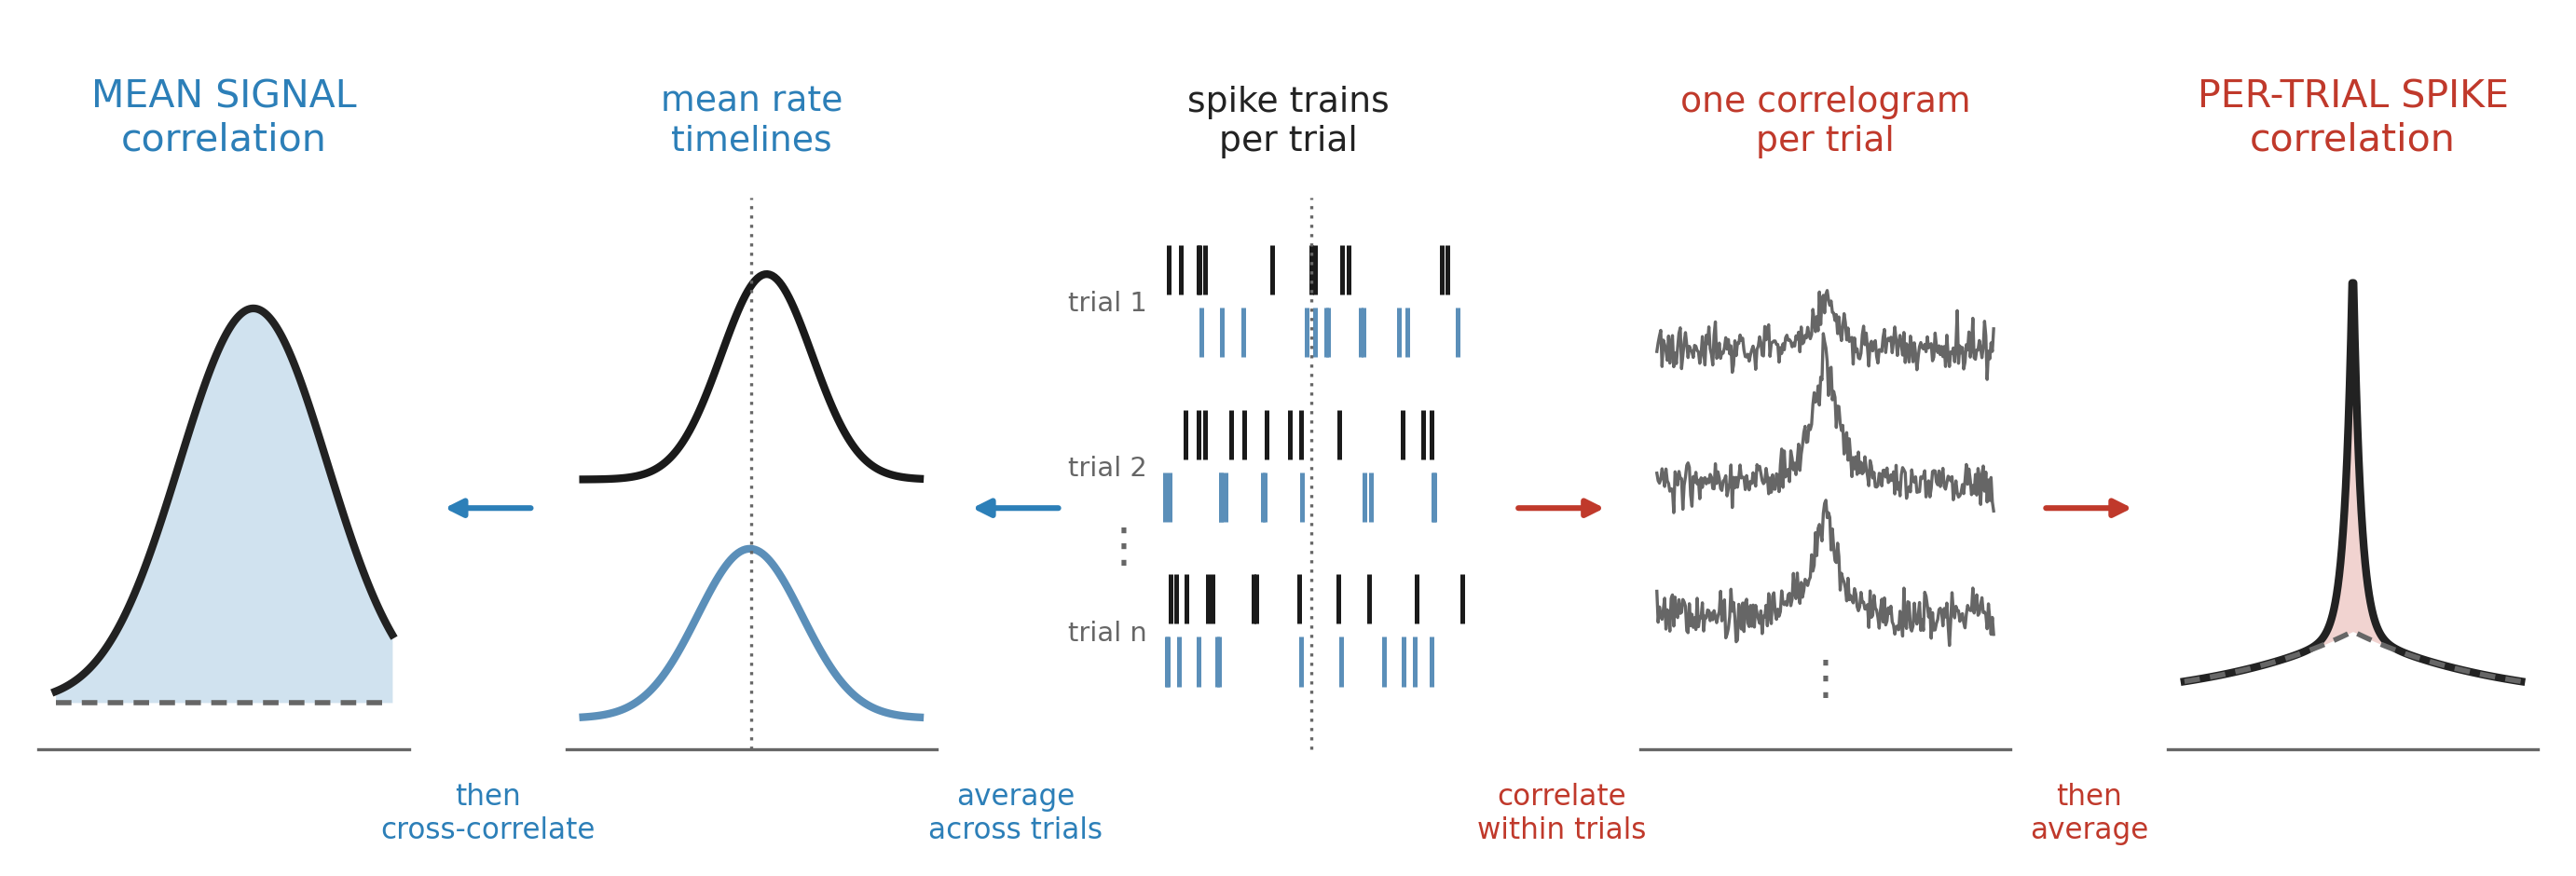

In [2]:
fig, paths = viz.plot_method_schematic(figs)
display(Image(filename=str(paths["png"])))

**Figure 1. The two measures differ in one step.** Both paths begin from the same
set of fixations (centre), in which two simultaneously recorded units each
contribute a 1 ms spike train over ±500 ms of fixation onset. *Leftward:* the
fixations are averaged into one mean rate timeline per unit, and the two timelines
are cross-correlated — **mean signal correlation**, shaded against its
cross-session null. *Rightward:* the two trains are cross-correlated within each
fixation and the resulting correlograms are averaged — **per-trial spike
correlation**, shaded against its circular-shift null. Averaging first is the only
difference between the two, and it is what removes trial-by-trial co-firing: the
left path can in principle be computed on units never recorded together, the right
path cannot. Traces are drawn from formulae, not data, so the axes carry no
values.

---

## Results

Both measures are loaded first, then reported within region and across regions in
turn. Each of those sections opens with its own denominators — how many pairs
were recorded, how many the selectivity rule keeps, and how many of those carry a
per-trial signal on their own — so a section can be read without paging back.

In [3]:
# --- per-trial spike correlation: per-fixation trains, circular-shift null ---
# Load every simultaneously recorded pair first.  The selectivity filter is what
# Figures 2 and 6 are about, so the unfiltered table has to survive long enough
# to be counted.
all_pairs = psc.load_pair_coordination(CFG_PATH)[0]
all_pairs, dropped = psc.drop_zero_lag_artifact_dates(all_pairs)
all_pairs["scope"] = np.where(all_pairs["same_region"], "within_region", "cross_region")

spikes = all_pairs.loc[all_pairs["both_selective"]].copy()
spike_traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
print(f"per-trial spike correlation: {len(spikes):,} pair-conditions, "
      f"both units FDR-selective   (artifact dates removed: {dropped})")

# --- mean signal correlation: condition-averaged timelines, cross-session null
signal_settings = sc.SignalCorrelationSettings(cfg_path=CFG_PATH)
units, timeline = sc.load_condition_timelines(signal_settings)
signal, signal_lags = sc.build_pair_correlations(units, timeline, signal_settings)
signal_traces = {
    "lags_ms": signal_lags,
    "traces": sc.build_group_traces(signal, signal_settings),
}
print(f"mean signal correlation: {len(signal):,} pairs from {len(units)} "
      f"FDR-selective units")

joined = sc.join_with_spike_correlation(
    signal, signal_settings, signal_metric=sc.WINDOW_METRIC,
    spike_metric=psc.WINDOW_METRIC,
)
correlations = sc.correlate_signal_with_spike_correlation(joined)

# Summaries and paired contrasts, computed once and reused by every figure.
spike_summary = psc.summarize_coordination(
    spikes, metric=SPIKE_METRIC, group_columns=("scope", "region_pair", "condition")
)
spike_contrasts = psc.compare_conditions(
    spikes, metric=SPIKE_METRIC, group_columns=("scope", "region_pair")
)
analysed_pairs = psc.summarize_analysed_pairs(all_pairs)
counts = psc.build_recording_counts(spikes)
pair_significance = psc.summarize_significant_pairs(spikes)

per-trial spike correlation: 113,163 pair-conditions, both units FDR-selective   (artifact dates removed: ['01172019', '09272018', '09292018'])


mean signal correlation: 5,206 pairs from 574 FDR-selective units


---

### Within region

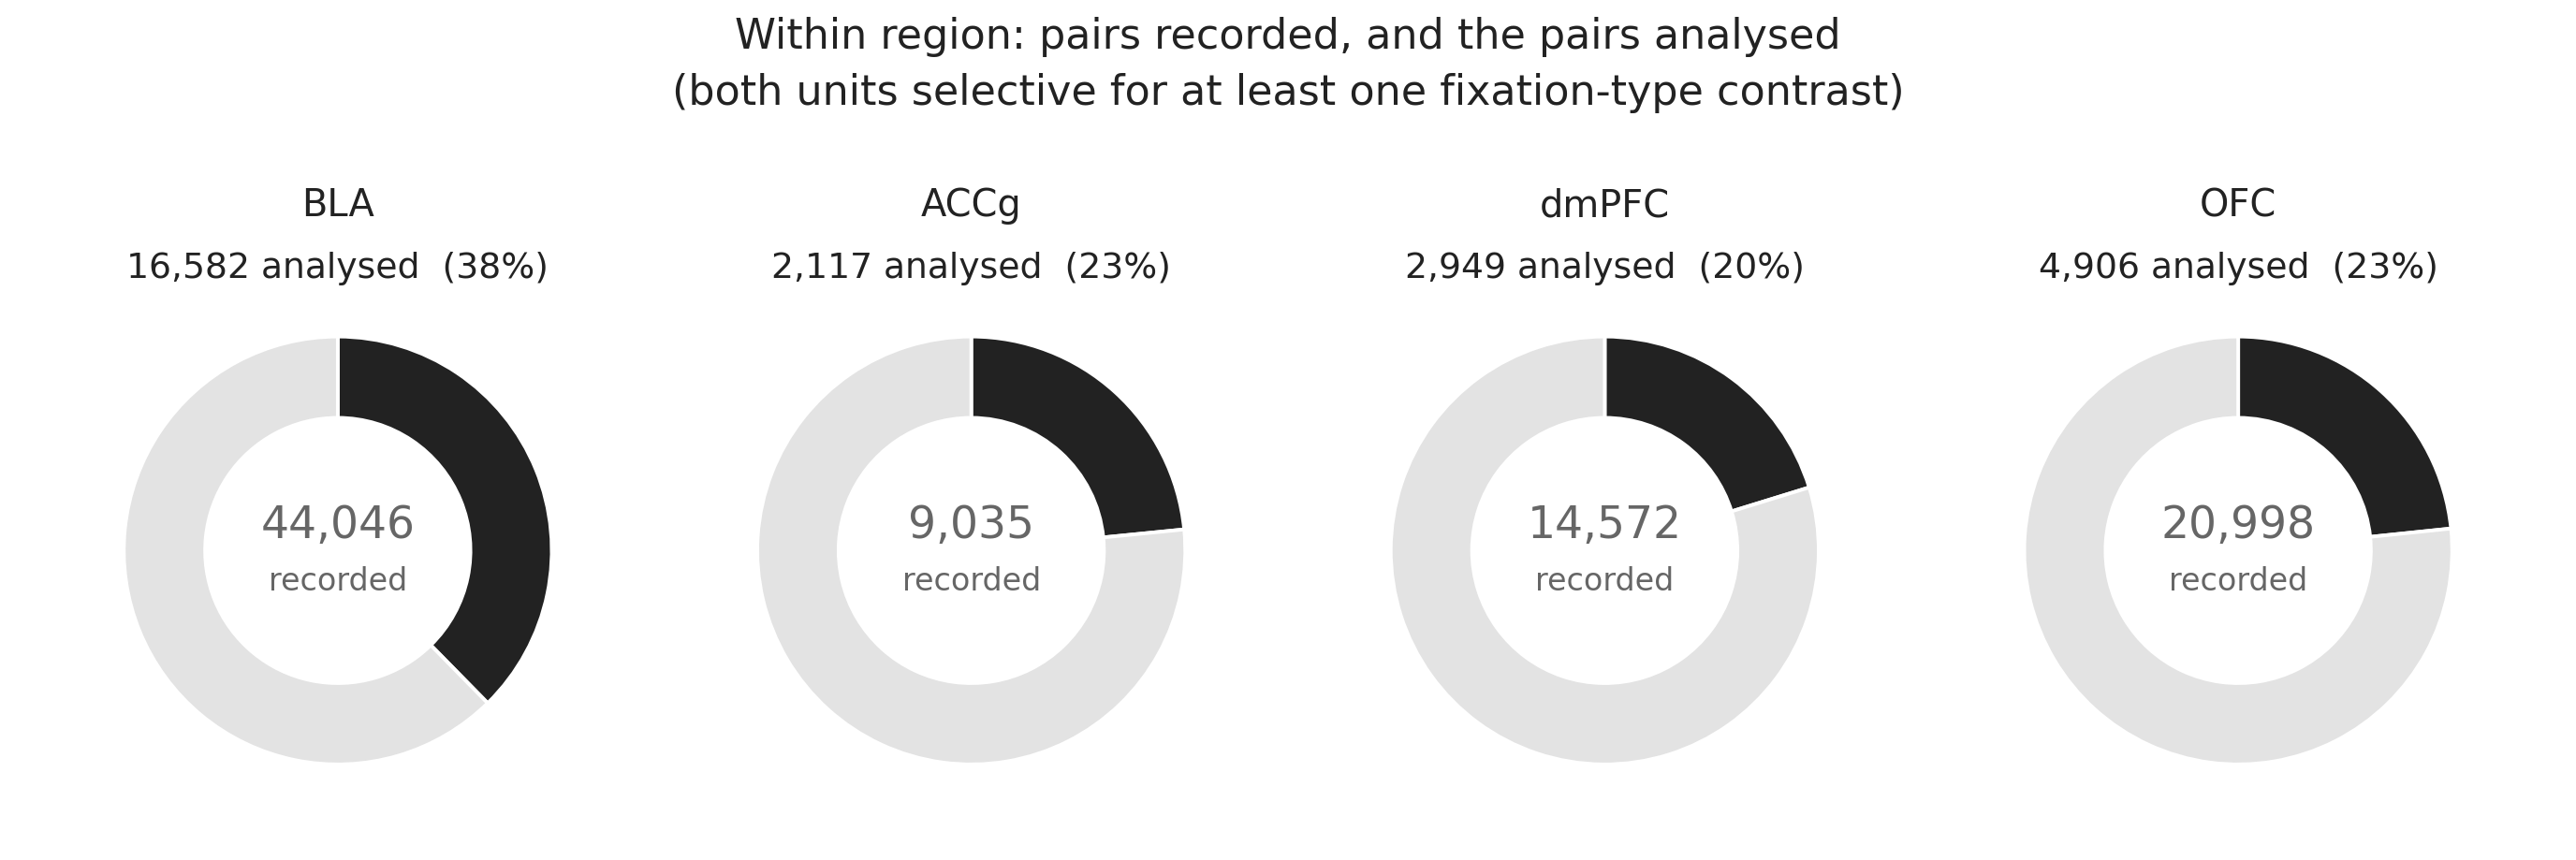

In [4]:
fig, paths = viz.plot_analysed_pair_pies(
    analysed_pairs, figs, scope="within_region", stem="fig02_analysed_pairs"
)
display(Image(filename=str(paths["png"])))

**Figure 2. Within-region pairs recorded, and pairs analysed.** One donut per
region. The number in the hole is every pair of simultaneously recorded units the
region contributes; the dark wedge, with its count and percentage above, is the
subset this chapter analyses — pairs in which **both** units are selective,
meaning significant for at least one fixation-type contrast after
multiple-comparison correction. Between a fifth and two fifths of recorded pairs
survive. The cost is steep because the rule is applied twice: requiring a
selective unit is a filter, requiring two at once is roughly its square, so BLA
keeps 38% of its pairs while 53% of its units are selective. Two things to read
off: the regions are very unequal — BLA supplies 16,582 analysed pairs against
ACCg's 2,117 — and the inclusion rate is similar across them (20–38%), so the
imbalance is in how much was recorded, not in how selectively each region was
filtered. Figures 3 to 5 are computed on the dark wedges only.

In [5]:
display(Markdown("**Recorded against analysed**"))
display(
    analysed_pairs.loc[analysed_pairs["scope"] == "within_region"]
    .drop(columns=["scope"]).round(3).reset_index(drop=True)
)

display(Markdown("**The analysed pairs**: units, recording days, sessions, and "
                 "fixations per pair-condition"))
display(
    counts.loc[
        counts["scope"] == "within_region",
        ["region_pair", "n_units", "n_dates", "n_sessions", "n_pairs",
         "median_pairs_per_session", "max_pairs_per_session", "median_n_fixations"],
    ].reset_index(drop=True)
)

display(Markdown("**Of the analysed pairs, how many are individually above the "
                 "circular-shift null** (FDR across all pair-and-condition tests "
                 "in a group, counted once per pair)"))
display(
    pair_significance.loc[pair_significance["scope"] == "within_region"]
    .drop(columns=["scope"]).round(5).reset_index(drop=True)
)

**Recorded against analysed**

,region_pair,n_recorded,n_analysed,frac_analysed,n_units_recorded,n_units_analysed,n_sessions,n_dates
0,bla,44046,16582,0.376,508,267,327,33
1,ofc,20998,4906,0.234,232,102,129,13
2,dmpfc,14572,2949,0.202,185,68,150,15
3,accg,9035,2117,0.234,191,89,166,17


**The analysed pairs**: units, recording days, sessions, and fixations per pair-condition

,region_pair,n_units,n_dates,n_sessions,n_pairs,median_pairs_per_session,max_pairs_per_session,median_n_fixations
0,bla,267,31,307,16582,15.0,528,120.0
1,ofc,102,12,120,4906,21.0,136,77.0
2,dmpfc,68,9,83,2949,10.0,105,106.0
3,accg,89,15,144,2117,10.0,78,51.0


**Of the analysed pairs, how many are individually above the circular-shift null** (FDR across all pair-and-condition tests in a group, counted once per pair)

,region_pair,n_pairs,n_tests,n_significant,frac_significant
0,accg,2117,5326,0,0.00000
1,bla,16582,39015,69,0.00416
2,dmpfc,2949,7054,55,0.01865
3,ofc,4906,13846,74,0.01508


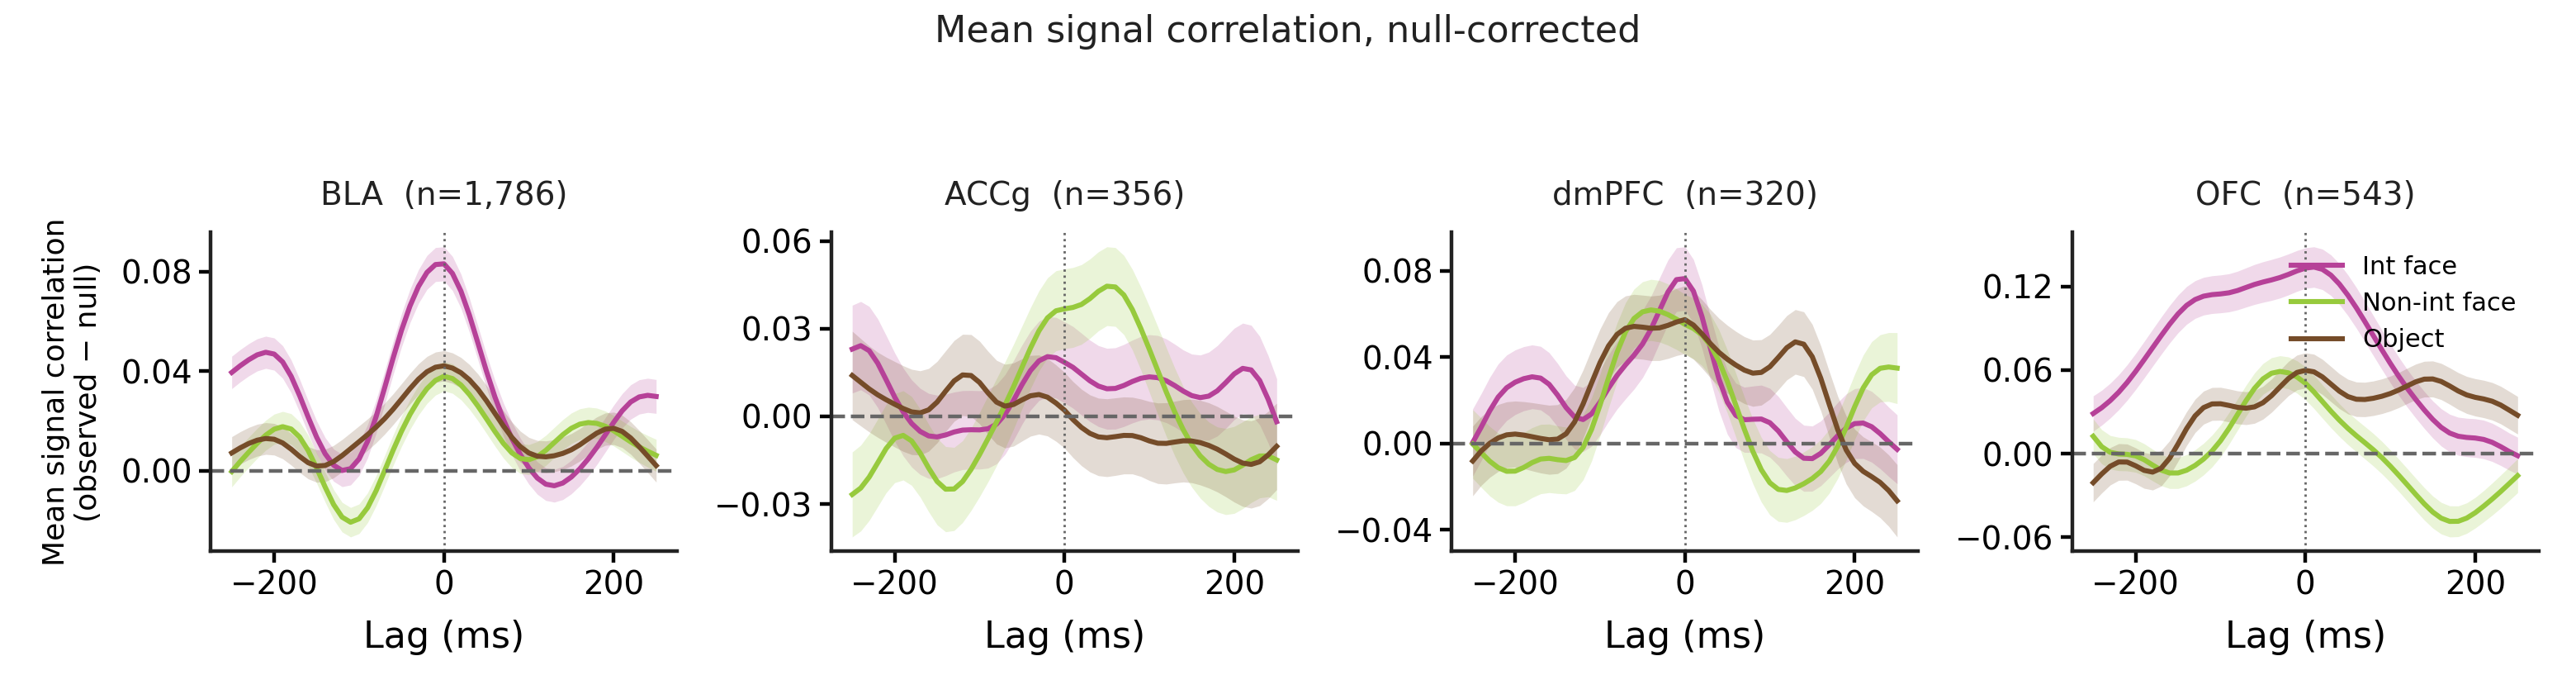

In [6]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="within_region", max_lag_ms=250.0,
    ylabel="Mean signal correlation\n(observed − null)",
    title="Mean signal correlation, null-corrected",
    stem="fig03_signal_excess",
)
display(Image(filename=str(paths["png"])))

**Figure 3. Mean signal correlation, within region.** Null-corrected correlation
between the two units' condition-averaged rate timelines, against lag, one panel
per region and one trace per fixation type (mean ± SEM across pairs). The
cross-session null is subtracted, so zero means "resembles a same-region unit from
another session no more than chance", and the dashed line at zero is that null,
not an axis. Interactive face is above the other two conditions in every region,
but only in BLA and OFC does the difference survive correction (Figure 5), and in
OFC it is several times larger than anywhere else.

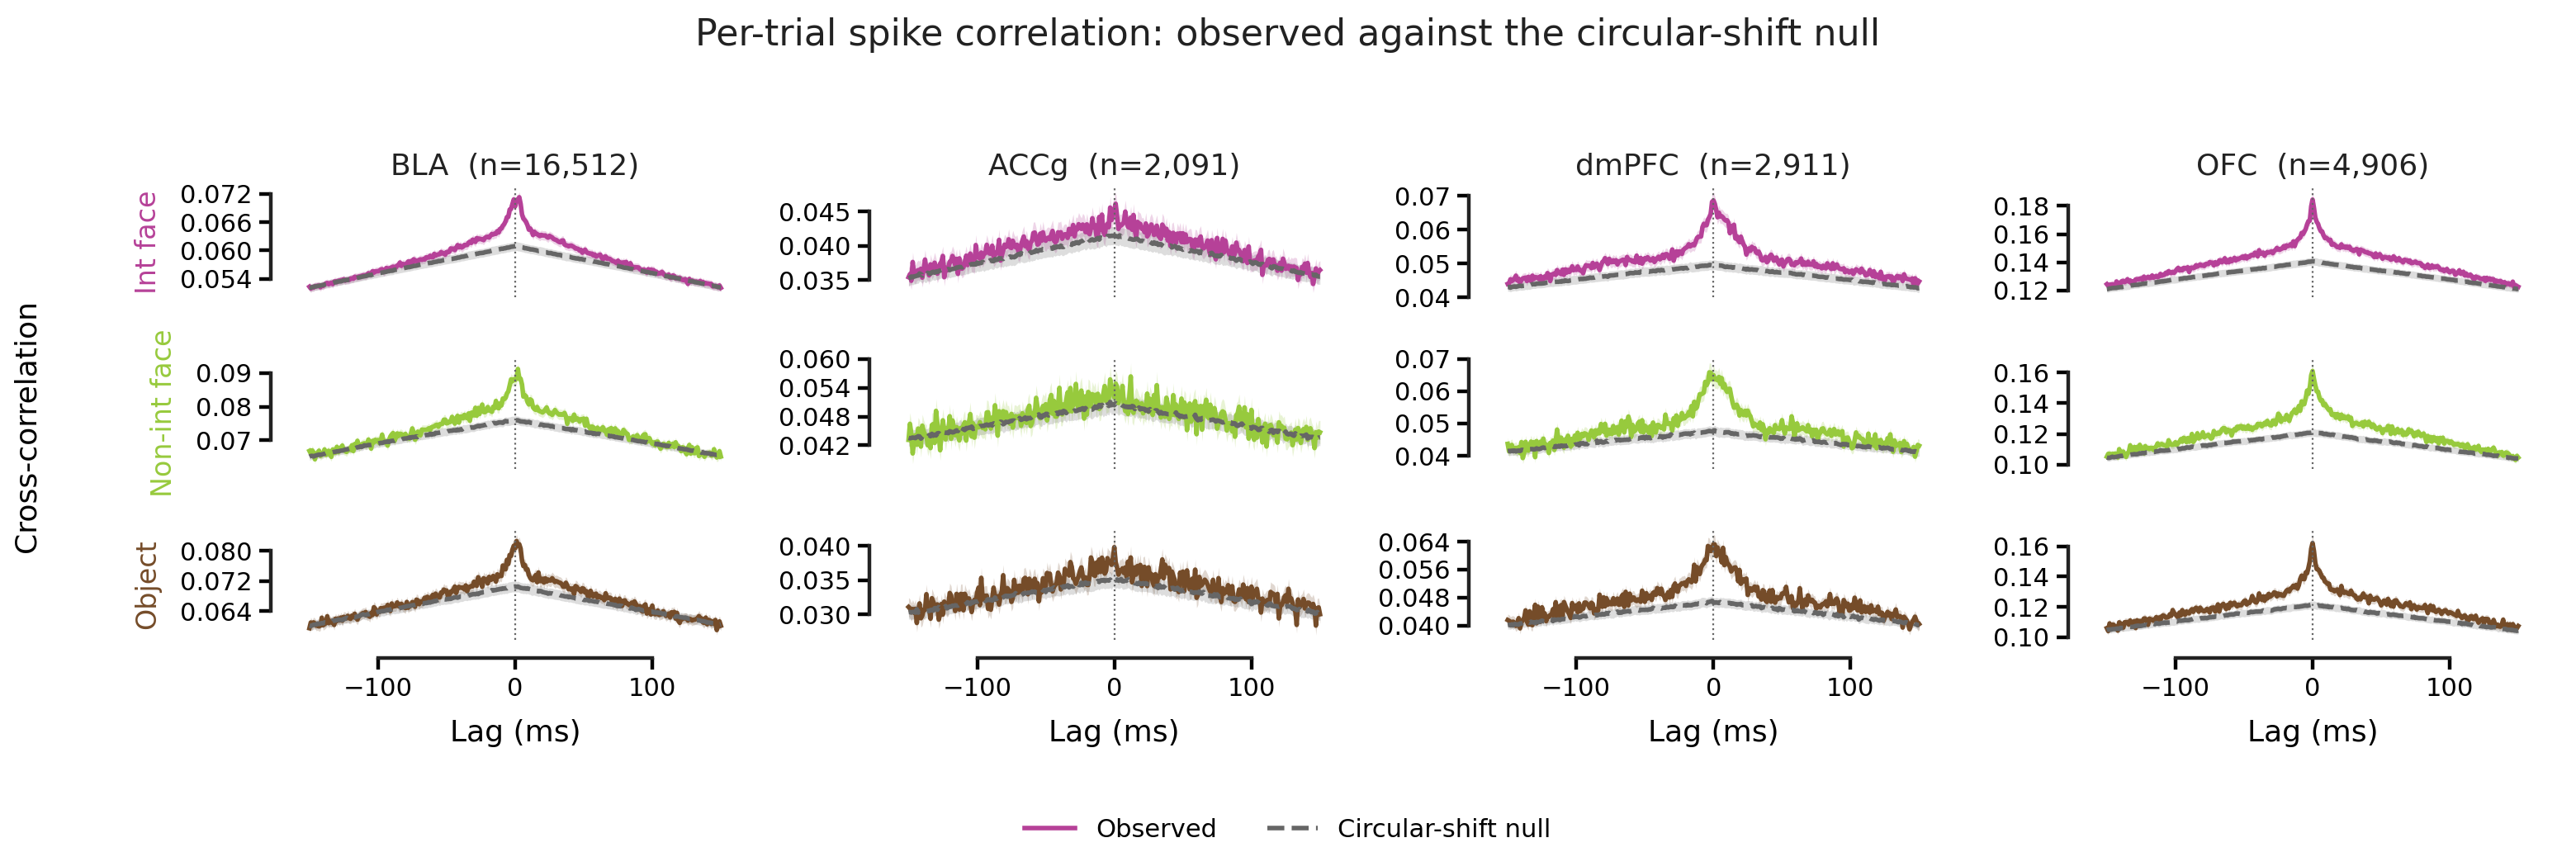

In [7]:
fig, paths = viz.plot_spike_correlation_above_null(
    spike_traces, figs, scope="within_region", stem="fig04_spike_above_null"
)
display(Image(filename=str(paths["png"])))

**Figure 4. Per-trial spike correlation against its null, within region.** Rows are
fixation types, columns are regions; the observed correlogram (colour) is plotted
against the circular-shift null (dashed grey), both mean ± SEM across pairs, with
pair counts in the column headings. The **gap between the two curves** is the
coordination — the observed curve alone is not, since an unnormalised
cross-correlation scales with the product of the two firing rates, which is why
the panels sit at different heights. The lag axis is identical in every panel and
is drawn once, on the bottom row. Every panel shows a clear gap, confirmed by the
one-sample Wilcoxon tests below. The three rows look alike; whether they *are*
alike is Figure 5's question, since three near-identical pairs of curves in
adjacent panels is not a comparison a reader can make by eye.

In [8]:
display(Markdown("**Is each group above its null?**  One-sample Wilcoxon of the "
                 "per-pair ±250 ms excess against zero."))
display(
    psc.test_against_null(
        spikes.loc[spikes["scope"] == "within_region"], metric=psc.WINDOW_METRIC,
        group_columns=("region_pair", "condition"),
    ).loc[:, ["region_pair", "condition", "n_pairs", "mean_excess", "p_value"]]
)

**Is each group above its null?**  One-sample Wilcoxon of the per-pair ±250 ms excess against zero.

,region_pair,condition,n_pairs,mean_excess,p_value
0,accg,face_interactive,2091,0.000778,2.371621e-40
1,accg,face_non_interactive,1394,0.000552,8.246894e-08
2,accg,object,1841,0.000603,2.619421e-23
3,bla,face_interactive,16512,0.000938,0.000000e+00
4,bla,face_non_interactive,10352,0.001295,1.447779e-136
5,bla,object,12151,0.000927,7.900848e-105
6,dmpfc,face_interactive,2911,0.002805,1.676758e-155
7,dmpfc,face_non_interactive,2135,0.002005,1.217832e-52
8,dmpfc,object,2008,0.002329,2.711200e-55
9,ofc,face_interactive,4906,0.005524,1.496743e-263


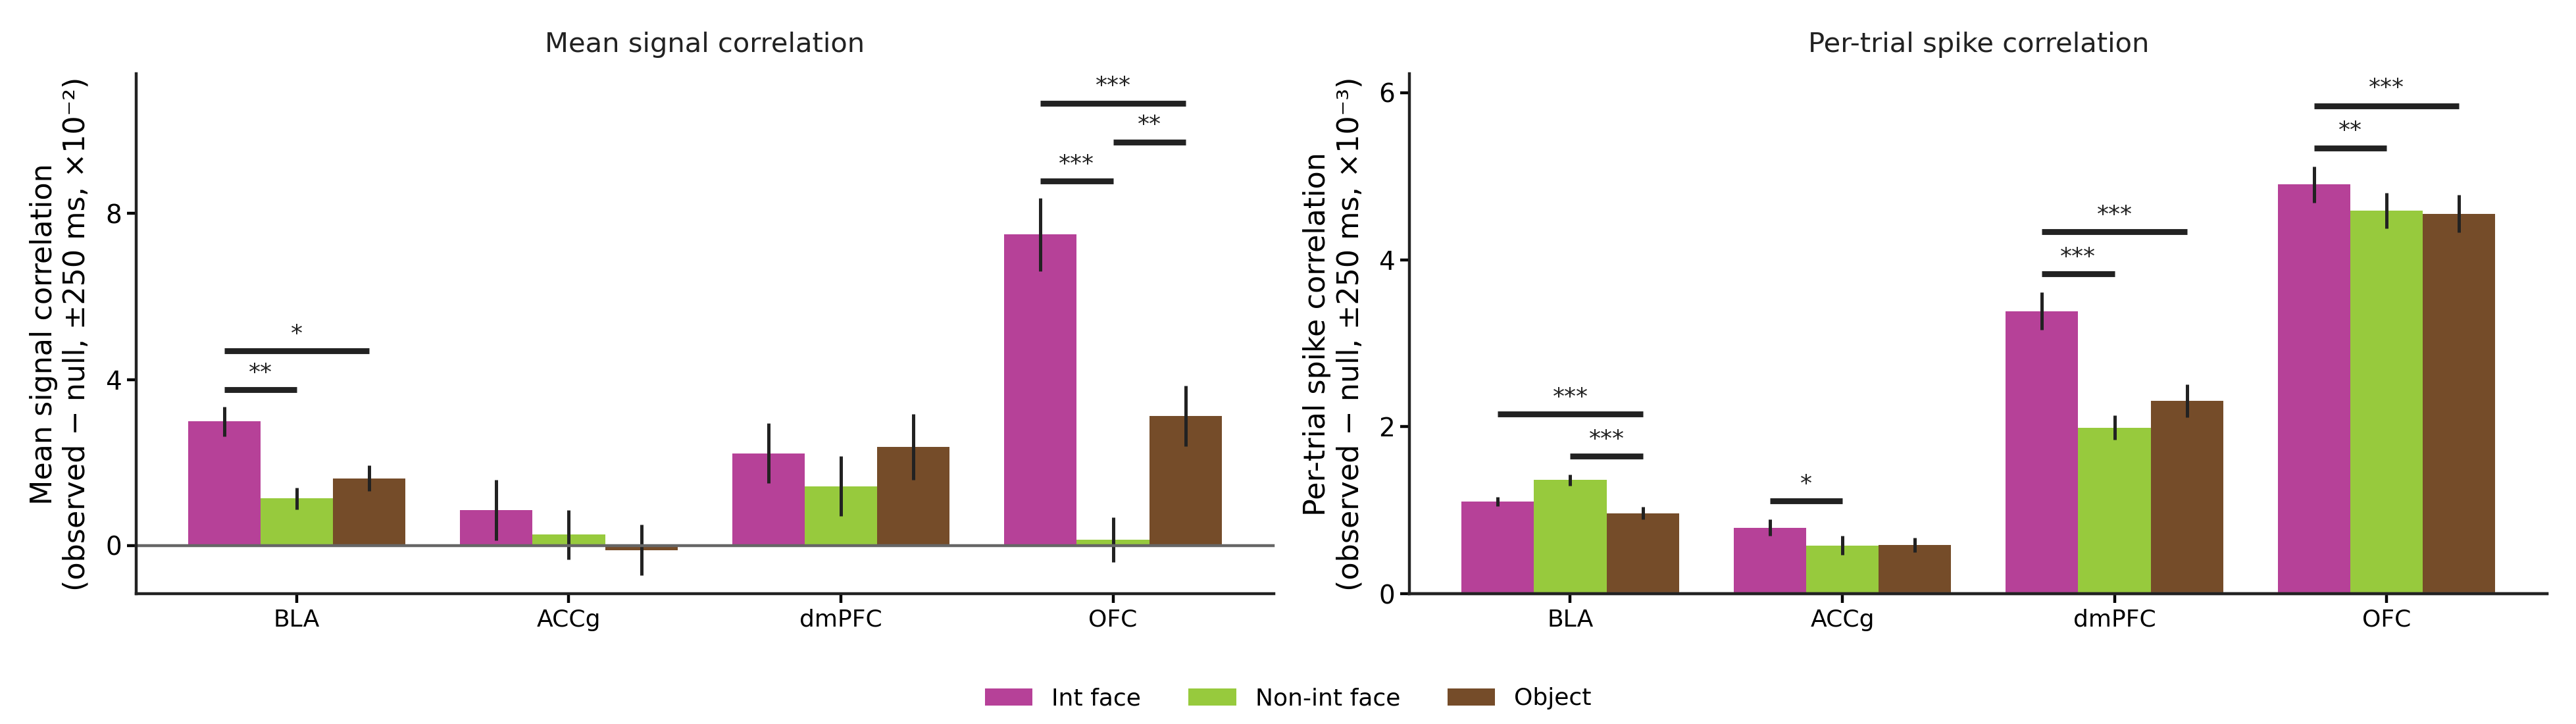

In [9]:
signal_summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)
signal_contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)

fig, paths = viz.plot_correlation_bars(
    signal_summary, signal_contrasts, spike_summary, spike_contrasts, figs,
    scope="within_region", stem="fig05_correlation_bars",
)
display(Image(filename=str(paths["png"])))

**Figure 5. The two measures side by side, within region.** Each curve above,
reduced to one number: its mean over ±250 ms, minus its null's. *Left:* mean
signal correlation, a Pearson coefficient. *Right:* per-trial spike correlation on
the trial-count-matched recomputation, in spike pairs per fixation. Bars are
mean ± SEM across pairs; a horizontal bar with stars marks every paired Wilcoxon
contrast surviving FDR within the panel, and nothing is marked where the contrast
does not survive. Each panel is scaled to its own decade, named in its axis
label — the per-trial panel reads ×10⁻³ here and ×10⁻⁴ in Figure 9, so the
ten-fold drop across regions is a symbol rather than a count of leading zeros. The
two y-axes are different quantities and are not comparable in magnitude; only the
*pattern across fixation types* is. That pattern is the chapter's result:
interactive face leads on both measures in OFC and dmPFC, but the mean-signal
effect sizes reach 0.30 where the per-trial ones reach 0.073.

In [10]:
display(Markdown("**Mean signal correlation** — group means, then paired contrasts"))
display(
    signal_summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)
display(
    signal_contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)

display(Markdown("**Per-trial spike correlation** — group means (×10⁻³), then paired "
                 "contrasts, on the trial-count-matched recomputation"))
display(
    spike_summary.loc[spike_summary["scope"] == "within_region"]
    .pivot_table(index="region_pair", columns="condition", values="mean")
    .mul(1e3).round(3)
)
display(
    spike_contrasts.loc[
        spike_contrasts["scope"] == "within_region",
        ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
         "effect_size_rank_biserial", "p_value_corrected", "significant"],
    ].round(5)
)

**Mean signal correlation** — group means, then paired contrasts

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.0085,0.0026,-0.0011
bla,0.0299,0.0113,0.0162
dmpfc,0.0222,0.0143,0.0238
ofc,0.0749,0.0014,0.0312


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg,face_interactive,face_non_interactive,356,0.0059,-0.0112,0.9462,False
1,accg,face_interactive,object,356,0.0096,0.0169,0.9130,False
2,accg,face_non_interactive,object,356,0.0037,0.0506,0.9130,False
3,bla,face_interactive,face_non_interactive,1786,0.0186,0.0705,0.0029,True
4,bla,face_interactive,object,1786,0.0137,0.0448,0.0108,True
5,bla,face_non_interactive,object,1786,-0.0049,0.0034,0.9130,False
6,dmpfc,face_interactive,face_non_interactive,320,0.0079,0.0125,0.9130,False
7,dmpfc,face_interactive,object,320,-0.0016,0.0125,0.9130,False
8,dmpfc,face_non_interactive,object,320,-0.0095,-0.0500,0.9130,False
9,ofc,face_interactive,face_non_interactive,543,0.0735,0.2965,0.0000,True


**Per-trial spike correlation** — group means (×10⁻³), then paired contrasts, on the trial-count-matched recomputation

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.794,0.582,0.586
bla,1.107,1.364,0.967
dmpfc,3.385,1.990,2.312
ofc,4.900,4.588,4.550


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
12,accg,face_interactive,face_non_interactive,1356,0.00032,0.06421,0.04525,True
13,accg,face_interactive,object,1521,0.00027,0.01907,0.21468,False
14,accg,face_non_interactive,object,1323,-0.00001,0.00227,0.87698,False
15,bla,face_interactive,face_non_interactive,9391,0.00006,0.00373,0.79273,False
16,bla,face_interactive,object,10012,0.00038,0.03712,0.00000,True
17,bla,face_non_interactive,object,8479,0.00038,0.03952,0.00003,True
18,dmpfc,face_interactive,face_non_interactive,1906,0.00168,0.07312,0.00005,True
19,dmpfc,face_interactive,object,1813,0.00195,0.07182,0.00000,True
20,dmpfc,face_non_interactive,object,1609,-0.00027,-0.00933,0.71767,False
21,ofc,face_interactive,face_non_interactive,4288,0.00062,0.03685,0.00858,True


---

### Across regions

A cross-region pair exists only where both regions were recorded in the same
session, which was not true uniformly. Only BLA × ACCg, BLA × dmPFC and BLA × OFC
are populated enough to report: ACCg and OFC were never recorded together, and
dmPFC × OFC comes from a handful of sessions.

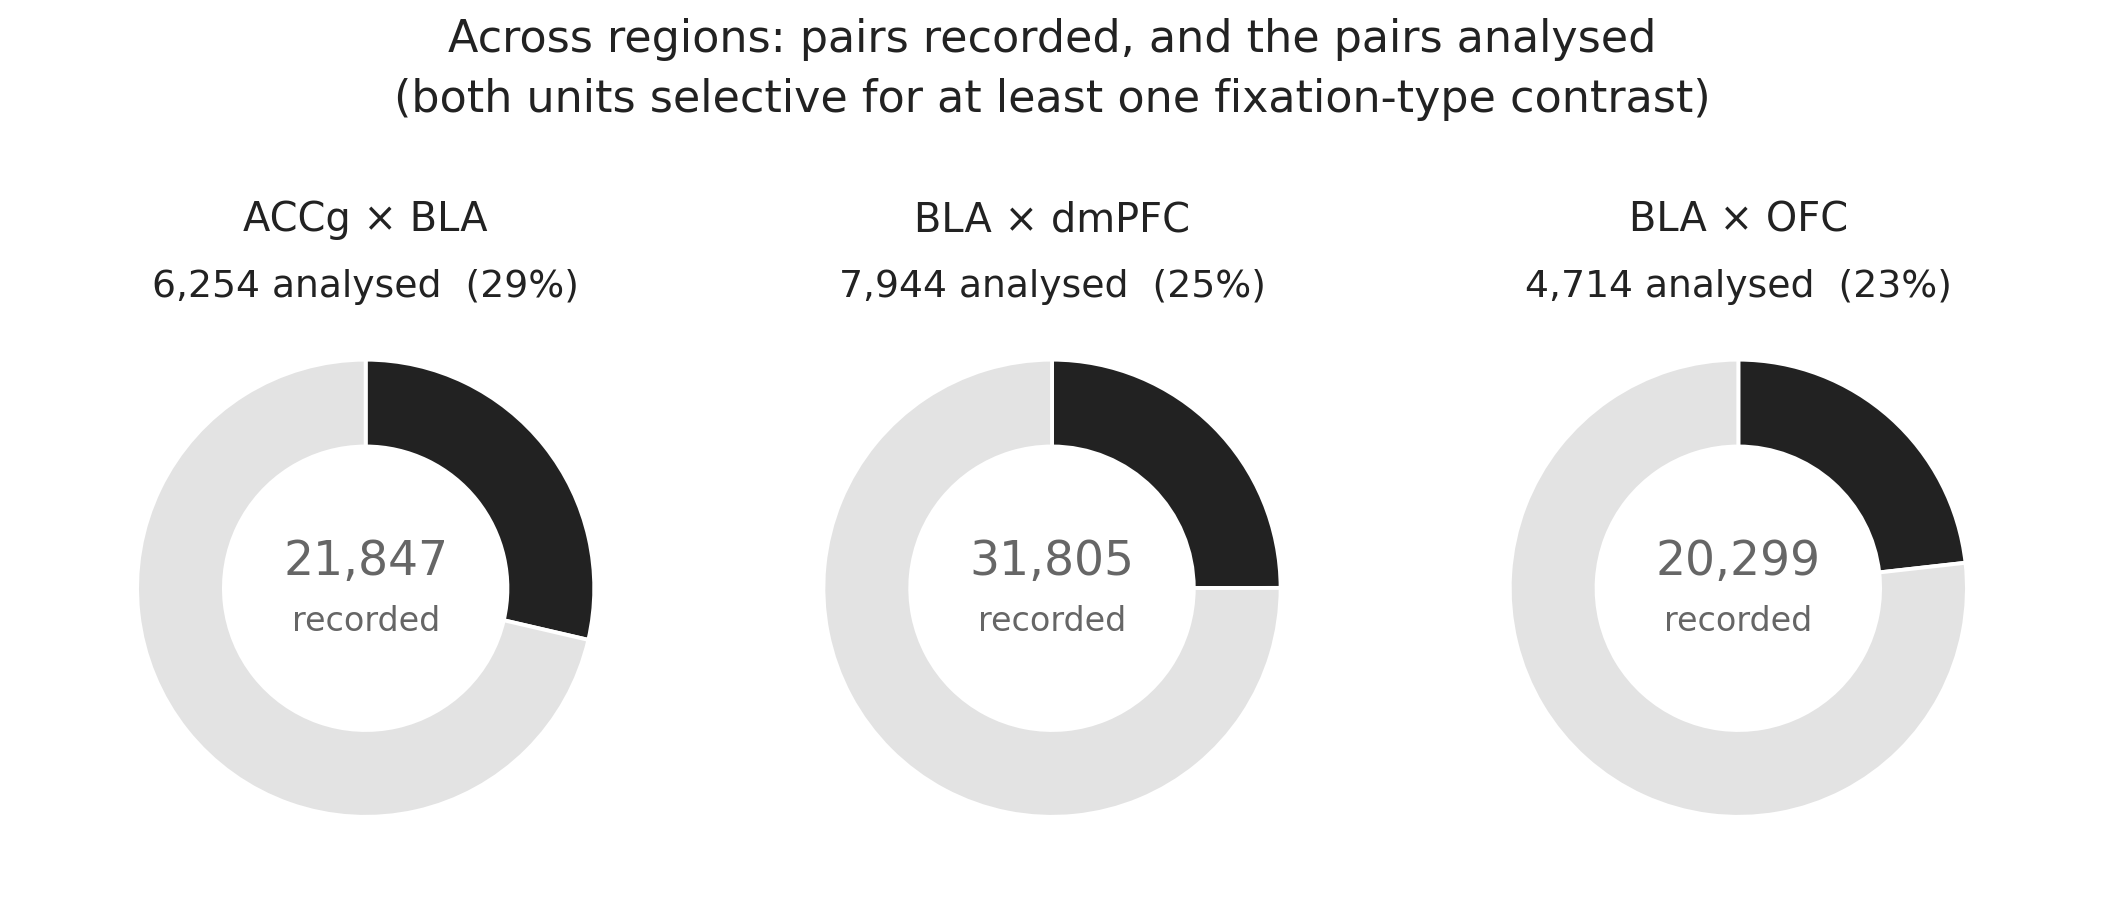

In [11]:
fig, paths = viz.plot_analysed_pair_pies(
    analysed_pairs, figs, scope="cross_region", stem="fig06_analysed_pairs"
)
display(Image(filename=str(paths["png"])))

**Figure 6. Cross-region pairs recorded, and pairs analysed.** As Figure 2, for the
three reportable cross-region combinations. The inclusion rate is the same
20–29% as within region, which is the point of showing it separately: the
cross-region results that follow are weak, and it is worth establishing that they
do not rest on less data or on a harsher filter. They rest on 4,714–7,944 analysed
pairs each, comparable with OFC's 4,906 within region.

In [12]:
display(Markdown("**Recorded against analysed**"))
display(
    analysed_pairs.loc[analysed_pairs["scope"] == "cross_region"]
    .drop(columns=["scope"]).round(3).reset_index(drop=True)
)

display(Markdown("**The analysed pairs**: units, recording days, sessions, and "
                 "fixations per pair-condition"))
display(
    counts.loc[
        counts["scope"] == "cross_region",
        ["region_pair", "n_units", "n_dates", "n_sessions", "n_pairs",
         "median_pairs_per_session", "max_pairs_per_session", "median_n_fixations"],
    ].reset_index(drop=True)
)

display(Markdown("**Of the analysed pairs, how many are individually above the "
                 "circular-shift null** (FDR across all pair-and-condition tests "
                 "in a group, counted once per pair)"))
display(
    pair_significance.loc[pair_significance["scope"] == "cross_region"]
    .drop(columns=["scope"]).round(5).reset_index(drop=True)
)

**Recorded against analysed**

,region_pair,n_recorded,n_analysed,frac_analysed,n_units_recorded,n_units_analysed,n_sessions,n_dates
0,bla-dmpfc,31805,7944,0.250,469,235,150,15
1,accg-bla,21847,6254,0.286,373,194,127,13
2,bla-ofc,20299,4714,0.232,313,141,110,11
3,accg-dmpfc,4858,334,0.069,153,37,89,9
4,dmpfc-ofc,122,0,0.000,9,0,10,1


**The analysed pairs**: units, recording days, sessions, and fixations per pair-condition

,region_pair,n_units,n_dates,n_sessions,n_pairs,median_pairs_per_session,max_pairs_per_session,median_n_fixations
0,bla-dmpfc,235,14,140,7944,32.0,300,116.0
1,accg-bla,194,12,115,6254,39.0,231,105.0
2,bla-ofc,141,11,107,4714,25.0,119,80.0
3,accg-dmpfc,37,6,58,334,5.5,18,101.5


**Of the analysed pairs, how many are individually above the circular-shift null** (FDR across all pair-and-condition tests in a group, counted once per pair)

,region_pair,n_pairs,n_tests,n_significant,frac_significant
0,accg-bla,6254,15407,4,0.00064
1,accg-dmpfc,334,730,0,0.00000
2,bla-dmpfc,7944,19309,0,0.00000
3,bla-ofc,4714,12476,0,0.00000


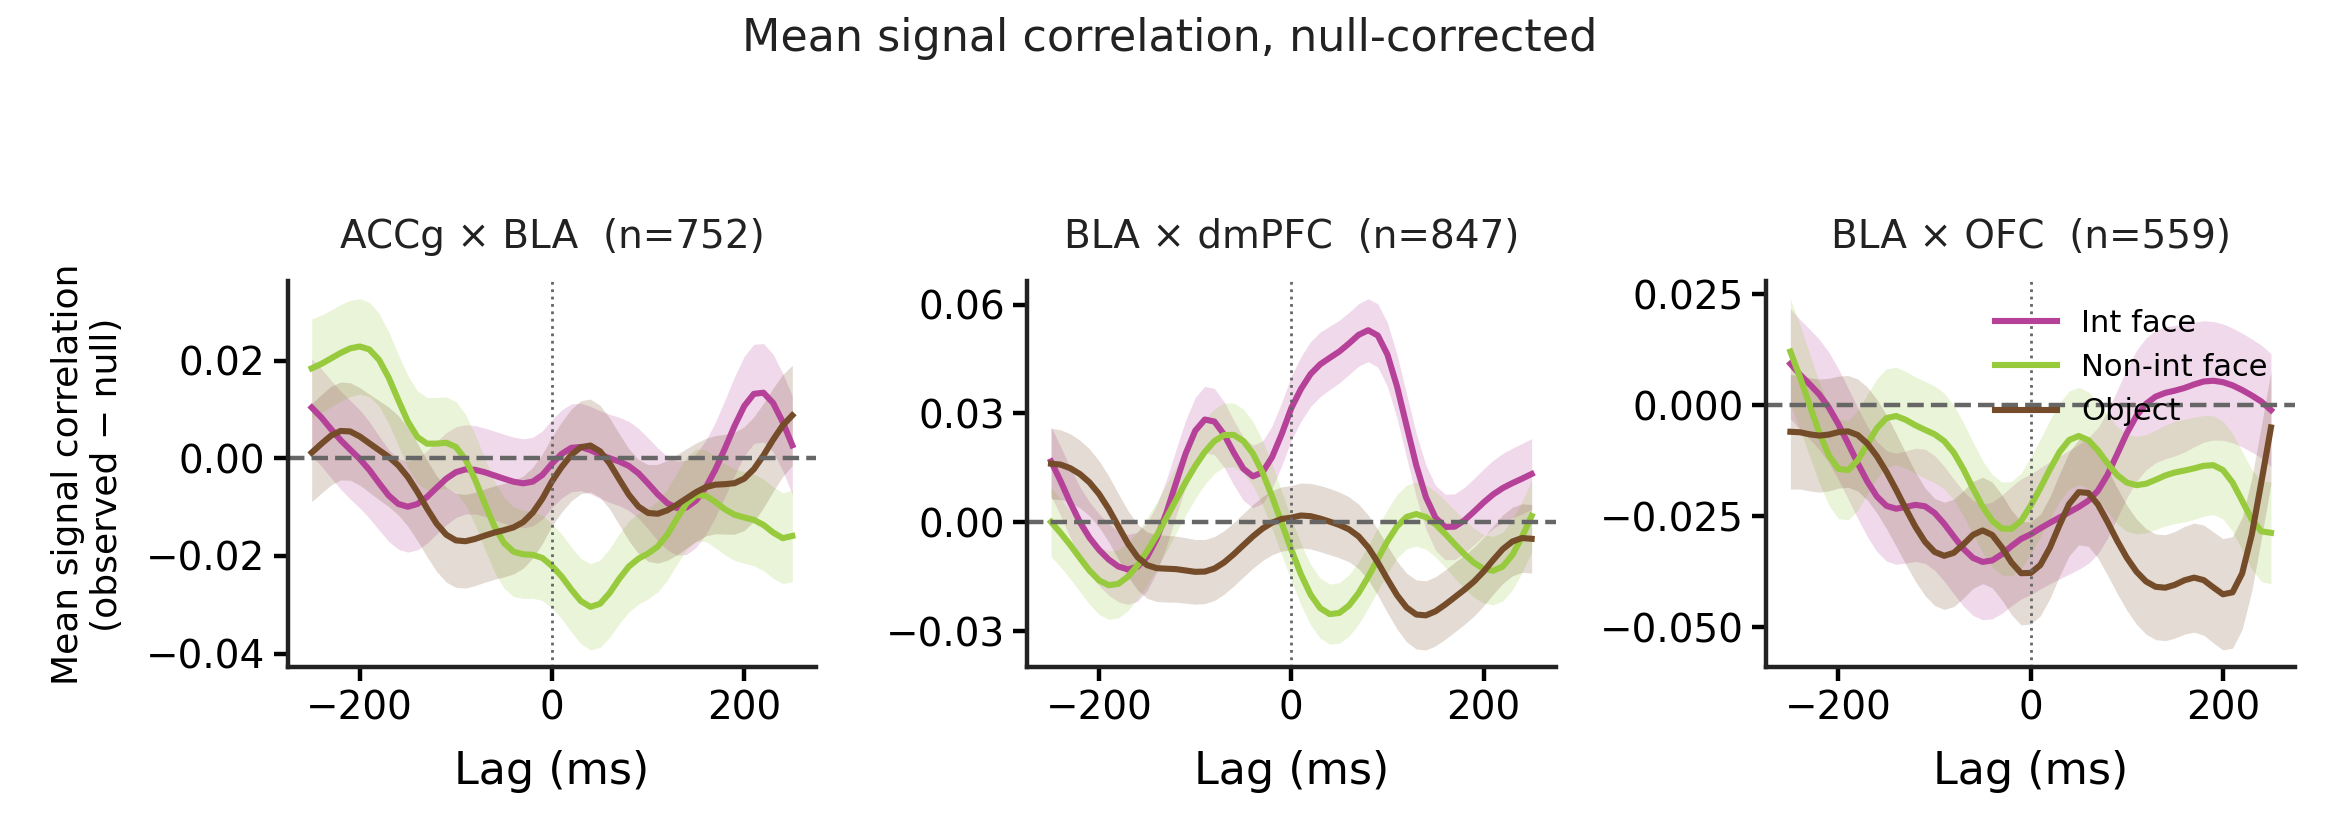

In [13]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="cross_region", max_lag_ms=250.0,
    ylabel="Mean signal correlation\n(observed − null)",
    title="Mean signal correlation, null-corrected",
    stem="fig07_signal_excess",
)
display(Image(filename=str(paths["png"])))

**Figure 7. Mean signal correlation, across regions.** As Figure 3, for the three
reportable cross-region combinations. Most traces sit at or below zero — two units
in different regions resemble each other no more than a unit from another session
does. BLA × dmPFC during interactive face is the exception and the only positive
cross-region trace in the chapter.

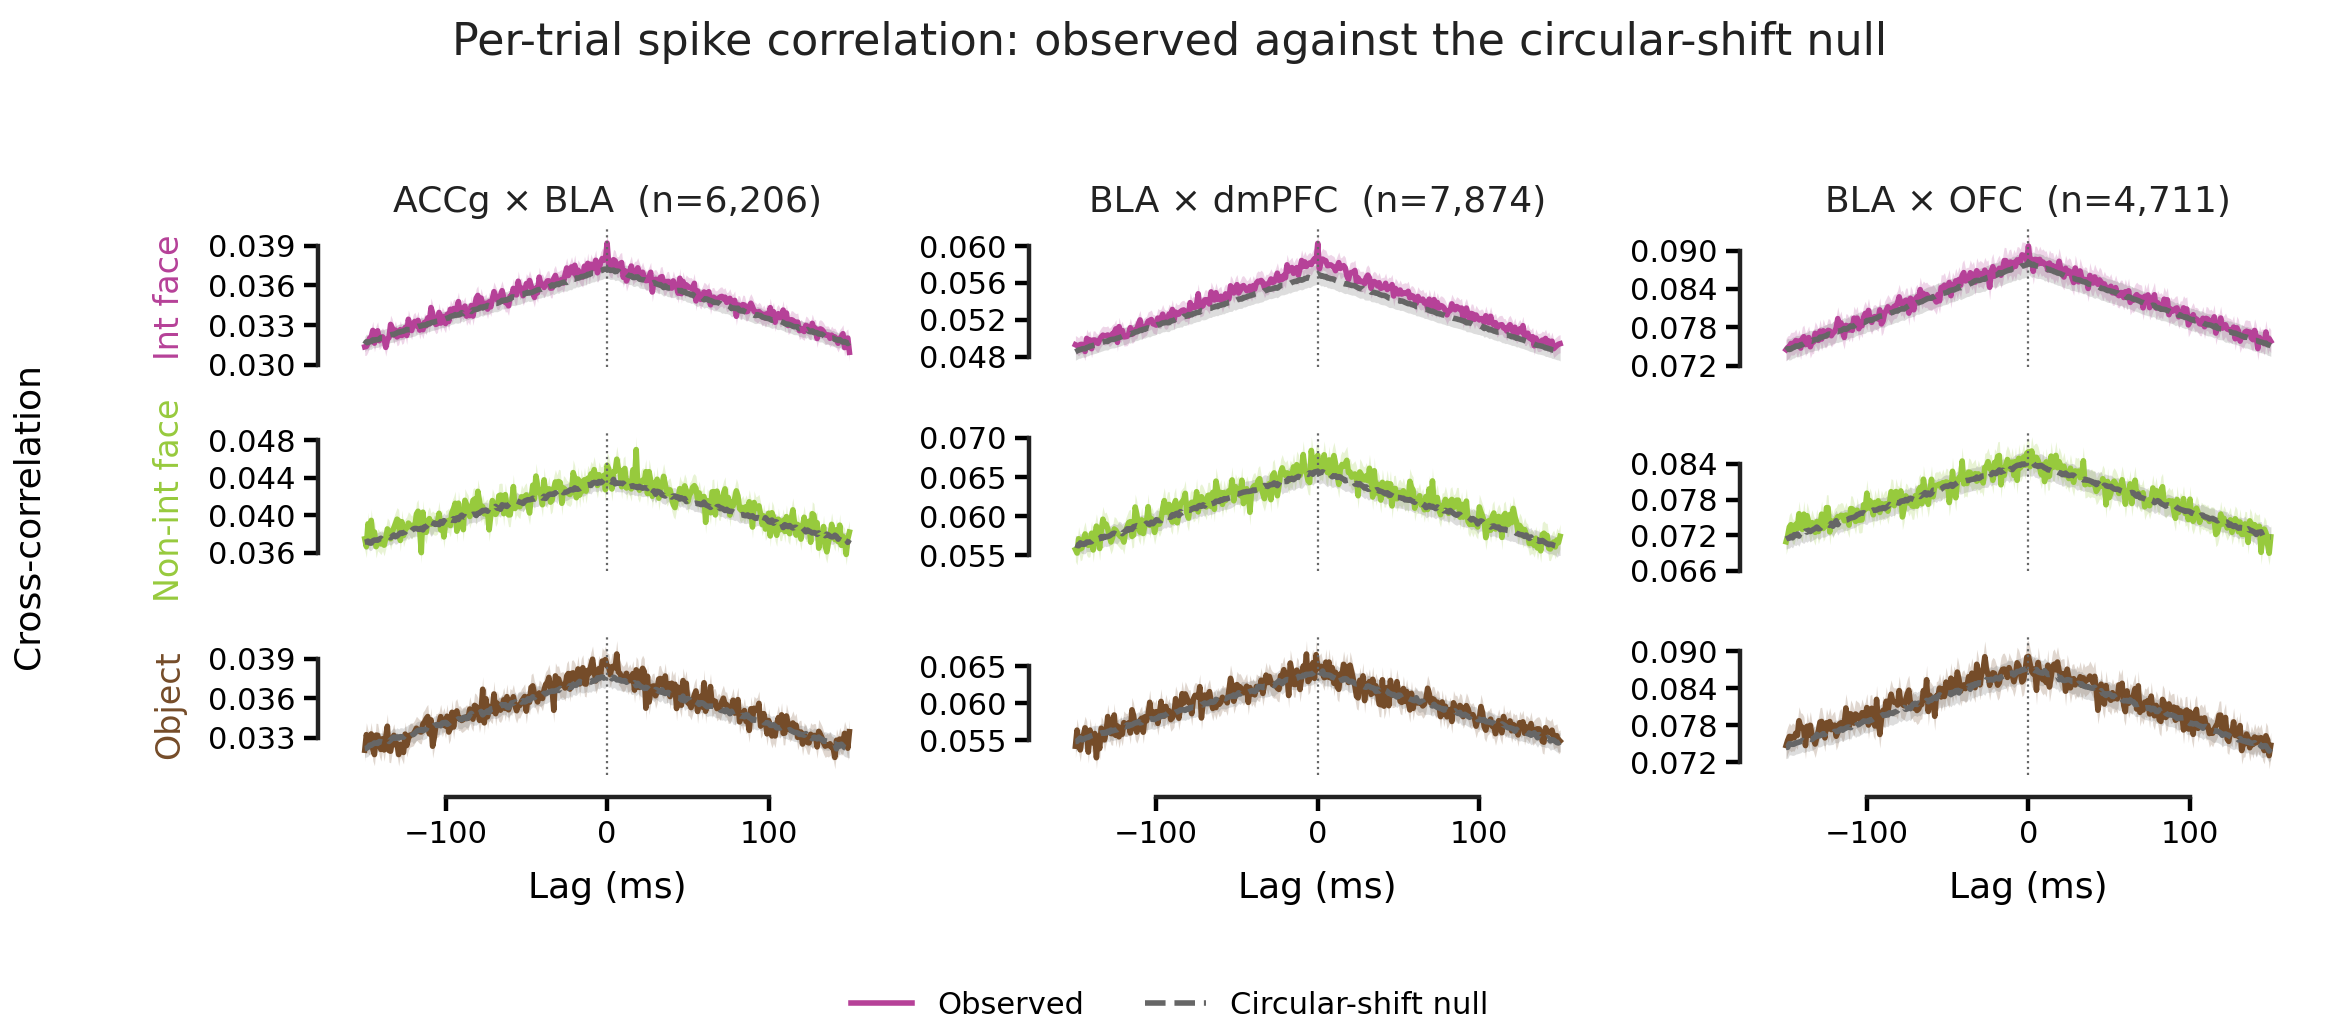

In [14]:
fig, paths = viz.plot_spike_correlation_above_null(
    spike_traces, figs, scope="cross_region", stem="fig08_spike_above_null"
)
display(Image(filename=str(paths["png"])))

**Figure 8. Per-trial spike correlation against its null, across regions.** As
Figure 4. The gaps are far narrower than within region, and in most panels the
observed curve tracks the null closely. BLA × dmPFC during interactive face is
again the panel where observed sits visibly above null across the whole lag range.

In [15]:
display(Markdown("**Is each group above its null?**  One-sample Wilcoxon of the "
                 "per-pair ±250 ms excess against zero."))
display(
    psc.test_against_null(
        spikes.loc[spikes["scope"] == "cross_region"], metric=psc.WINDOW_METRIC,
        group_columns=("region_pair", "condition"),
    ).loc[:, ["region_pair", "condition", "n_pairs", "mean_excess", "p_value"]]
)

**Is each group above its null?**  One-sample Wilcoxon of the per-pair ±250 ms excess against zero.

,region_pair,condition,n_pairs,mean_excess,p_value
0,accg-bla,face_interactive,6206,0.000172,2.141814e-10
1,accg-bla,face_non_interactive,4049,0.000319,7.291089e-06
2,accg-bla,object,5152,0.000126,3.649937e-04
3,accg-dmpfc,face_interactive,324,0.000140,4.933008e-04
4,accg-dmpfc,face_non_interactive,178,0.000379,3.764479e-02
5,accg-dmpfc,object,228,0.000170,2.878701e-02
6,bla-dmpfc,face_interactive,7874,0.000587,1.028523e-72
7,bla-dmpfc,face_non_interactive,5568,0.000339,3.692249e-06
8,bla-dmpfc,object,5867,0.000138,2.115177e-04
9,bla-ofc,face_interactive,4711,0.000369,2.271435e-07


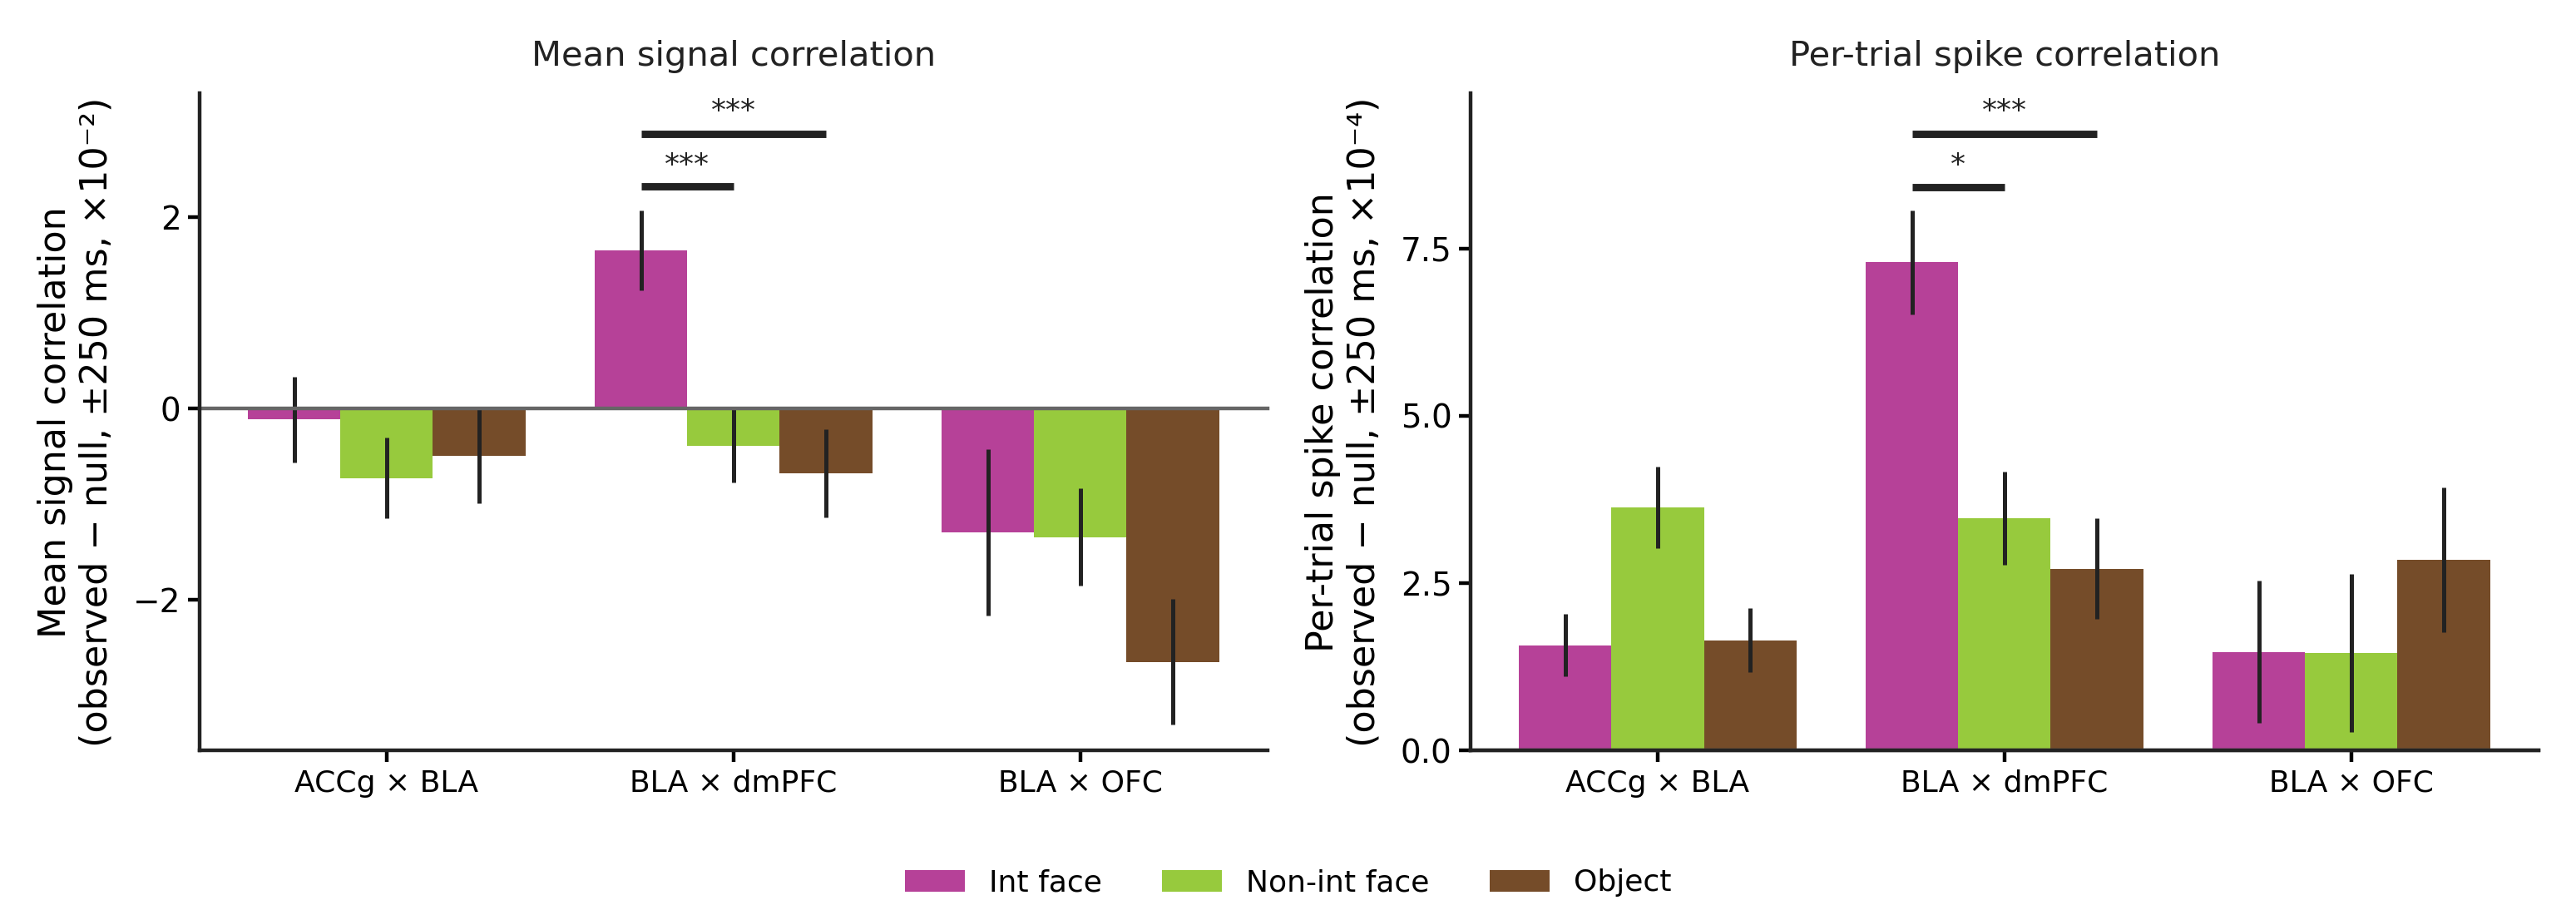

In [16]:
signal_summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)
signal_contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)

fig, paths = viz.plot_correlation_bars(
    signal_summary, signal_contrasts, spike_summary, spike_contrasts, figs,
    scope="cross_region", stem="fig09_correlation_bars",
)
display(Image(filename=str(paths["png"])))

**Figure 9. The two measures side by side, across regions.** As Figure 5. Read the
decade in each axis label before the bar heights: the per-trial panel is ×10⁻⁴
here against ×10⁻³ in Figure 5, so cross-region co-firing is an order of magnitude
weaker than within-region, and mean signal correlation is negative for most
combinations. Only BLA × dmPFC separates the fixation types, with interactive face
above both others on **both** measures — the same combination, the same direction,
the only place in the chapter where the two agree on a cross-region effect.

In [17]:
display(Markdown("**Mean signal correlation** — group means, then paired contrasts"))
display(
    signal_summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)
display(
    signal_contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)

display(Markdown("**Per-trial spike correlation** — group means (×10⁻³), then paired "
                 "contrasts, on the trial-count-matched recomputation"))
display(
    spike_summary.loc[spike_summary["scope"] == "cross_region"]
    .pivot_table(index="region_pair", columns="condition", values="mean")
    .mul(1e3).round(3)
)
display(
    spike_contrasts.loc[
        spike_contrasts["scope"] == "cross_region",
        ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
         "effect_size_rank_biserial", "p_value_corrected", "significant"],
    ].round(5)
)

**Mean signal correlation** — group means, then paired contrasts

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg-bla,-0.0011,-0.0072,-0.0050
bla-dmpfc,0.0166,-0.0039,-0.0068
bla-ofc,-0.0129,-0.0134,-0.0265


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg-bla,face_interactive,face_non_interactive,752,0.0061,0.0452,0.5120,False
1,accg-bla,face_interactive,object,752,0.0038,0.0532,0.6749,False
2,accg-bla,face_non_interactive,object,752,-0.0023,-0.0293,0.7487,False
3,bla-dmpfc,face_interactive,face_non_interactive,847,0.0205,0.1334,0.0002,True
4,bla-dmpfc,face_interactive,object,847,0.0233,0.1405,0.0002,True
5,bla-dmpfc,face_non_interactive,object,847,0.0029,-0.0106,0.7487,False
6,bla-ofc,face_interactive,face_non_interactive,559,0.0005,-0.0125,0.9056,False
7,bla-ofc,face_interactive,object,559,0.0136,0.0161,0.6749,False
8,bla-ofc,face_non_interactive,object,559,0.0131,0.0304,0.5120,False


**Per-trial spike correlation** — group means (×10⁻³), then paired contrasts, on the trial-count-matched recomputation

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg-bla,0.157,0.363,0.165
accg-dmpfc,0.111,0.363,0.160
bla-dmpfc,0.729,0.347,0.271
bla-ofc,0.147,0.146,0.285


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg-bla,face_interactive,face_non_interactive,3773,-0.00019,-0.00928,0.19639,False
1,accg-bla,face_interactive,object,4044,0.00003,0.00272,0.98210,False
2,accg-bla,face_non_interactive,object,3568,0.00021,0.02130,0.11155,False
3,accg-dmpfc,face_interactive,face_non_interactive,163,-0.00019,-0.01840,0.88820,False
4,accg-dmpfc,face_interactive,object,163,0.00004,0.03067,0.92746,False
5,accg-dmpfc,face_non_interactive,object,135,0.00019,-0.05185,0.88820,False
6,bla-dmpfc,face_interactive,face_non_interactive,5018,0.00036,0.03708,0.02255,True
7,bla-dmpfc,face_interactive,object,5191,0.00061,0.04180,0.00035,True
8,bla-dmpfc,face_non_interactive,object,4584,0.00009,-0.01178,0.99733,False
9,bla-ofc,face_interactive,face_non_interactive,3684,0.00004,-0.00081,0.86706,False


---

### Do the two measures track each other?

Reported as a table rather than a figure. The coefficients are positive in some
region-and-condition combinations and absent or negative in others, and plotting
them as bars would give a scattered set of values the visual weight of a result.

In [18]:
display(Markdown(
    "Spearman correlation across pairs between each pair's **mean signal "
    "correlation** and its **per-trial spike correlation**, both summarised as "
    "the mean over ±250 ms so the two ranked quantities are matched in "
    "construction."
))
display(
    correlations.loc[
        :, ["scope", "region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]
    ].round(4)
)

Spearman correlation across pairs between each pair's **mean signal correlation** and its **per-trial spike correlation**, both summarised as the mean over ±250 ms so the two ranked quantities are matched in construction.

,scope,region_pair,condition,n_pairs,spearman_rho,p_value
0,cross_region,accg-bla,face_interactive,734,0.0682,0.0647
1,cross_region,accg-bla,face_non_interactive,709,0.0128,0.7342
2,cross_region,accg-bla,object,713,0.0498,0.1840
3,cross_region,bla-dmpfc,face_interactive,847,0.0090,0.7937
4,cross_region,bla-dmpfc,face_non_interactive,814,0.1325,0.0001
5,cross_region,bla-dmpfc,object,810,0.0585,0.0960
6,cross_region,bla-ofc,face_interactive,505,-0.0076,0.8652
7,cross_region,bla-ofc,face_non_interactive,490,0.0740,0.1020
8,cross_region,bla-ofc,object,491,-0.0212,0.6386
9,within_region,accg,face_interactive,276,-0.0147,0.8073


## Discussion

### The fixation-condition effect is mostly in shared tuning

The clearest result is a dissociation of degree. Mean signal correlation differs
sharply between fixation conditions: interactive face is higher than both other
conditions in BLA ($r_{\\text{rb}} = 0.045$ and $0.071$) and, far more strongly, in
OFC ($0.19$ and $0.30$). Per-trial spike correlation moves in the same direction
but several times less far — the largest within-region effect is **0.073** (dmPFC,
interactive face against non-interactive) and most sit below 0.05, so a
"significant" contrast there describes a population split near 52% to 48%.

The two measures are computed from the same spike trains, on the same pairs, in
the same window, against equally conservative nulls. The difference between them
is one step — whether fixations are averaged before or after correlating. Figure 5
puts them on adjacent axes so that step is the only thing separating the two
patterns, and what interactive fixation changes is mostly **how much two neurons'
average responses resemble each other**, and only marginally how tightly they
co-fire within a fixation.

Framed in population terms, this is a change in the *representation* more than in
the *correlation structure*. It is the less common of the two findings in this
literature, where attention and state effects are usually reported on noise
correlation.

The qualification matters. The per-trial effect is not zero: in dmPFC and OFC
interactive face is above both other conditions with $r_{\\text{rb}}$ between 0.04
and 0.07, and it holds after trial-count matching, so it is not an artifact of
interactive fixations being more numerous. The honest statement is that both
measures move, and one moves several times further.

### Both forms of coupling exist, and are regionally organised

Neither result is a null. Per-trial spike correlation sits clearly above the
circular-shift null in every region and condition — a null that already preserves
each fixation's spike count and slow envelope, and so credits nothing to shared
excitability. Mean signal correlation sits clearly above a null built from real,
fixation-locked units of the same region.

The magnitudes are ordered the same way on both measures. OFC and dmPFC carry the
largest per-trial excess (≈ 4.7 and ≈ 2.6 $\\times 10^{-3}$), BLA and ACCg the
smallest (≈ 1.1 and ≈ 0.65 $\\times 10^{-3}$), and OFC also has the largest mean
signal correlation and by far the largest condition effect on it. ACCg is the
weakest on both and is the only region where no mean-signal contrast survives
correction at all. The one place the conditions invert is BLA's per-trial measure,
where non-interactive face is nominally highest — and that is also the one BLA
contrast that does not survive correction, so it is better read as an absence of
difference than as a reversal.

### The effect is a population shift, not a coupled subpopulation

The tables opening each results section carry a result that is easy to skip
past. The *population* of pairs sits above its null with p-values
indistinguishable from zero — down to $10^{-263}$ in OFC — but at most **1.9%** of
*individual* pairs survives FDR
correction across pairs (dmPFC), it is 1.5% in OFC and 0.4% in BLA, it is **zero**
in ACCg, and across regions it is 4 pairs out of 19,000. There is no subset of
strongly coupled pairs driving the average; there is a small, broadly distributed
shift in a large population. Any claim phrased in terms of "coordinated pairs"
would be describing one or two percent of the data.

### Shared tuning and co-firing are related, but only within a region

Pairs with more shared tuning also co-fire more, within region: OFC interactive
face reaches ρ = 0.54, dmPFC object ρ = 0.18, and all three BLA conditions are
positive with non-interactive face highest at ρ = 0.16. This is not automatic —
the two quantities come from different operations and either can exist without the
other — so a positive relationship says the same local circuitry plausibly
produces both. It does not hold everywhere: no ACCg combination reaches
significance, and dmPFC's interactive-face correlation is negative (ρ = −0.09,
n.s.) while its object correlation is the region's strongest. The relationship is
a feature of particular circuits and conditions rather than a general law, which
is why it is tabulated rather than plotted — a bar chart of it would give a
scattered set of coefficients the visual weight of a finding.

Across regions the relationship is all but absent — one of nine combinations
reaches significance (BLA × dmPFC, non-interactive face, ρ = 0.13) — and so is
most of the coupling. Cross-region per-trial excess is an order of magnitude below
within-region (≈ 0.15–0.73 $\\times 10^{-3}$ against 0.6–4.9), and cross-region
mean signal correlation is at or below zero for most combinations. The one
exception is **BLA × dmPFC during interactive face**, which stands above both
other conditions on *both* measures — $r_{\\text{rb}} = 0.13$ and $0.14$ on mean
signal correlation, $0.037$ and $0.042$ on the per-trial measure — and is the only
cross-region mean signal correlation anywhere in the chapter that is positive
rather than at or below its null. That it involves BLA and dmPFC specifically is
worth following up rather than treating as noise, but it is one comparison among
nine and should be replicated before it carries weight.

### Limitations

**Trial-count imbalance is the main threat to the mean-signal result.**
Interactive-face fixations outnumber the others roughly six to one, so
interactive-face mean timelines are estimated more precisely and correlate better
with anything. The cross-session null does not absorb this: the null partner
shares no tuning, so its correlation sits near zero whatever the precision. The
per-trial contrasts are trial-count matched and do not carry the problem; the mean
signal contrasts cannot be, because no matched average exists. Stratifying by the
interactive-to-object trial ratio bounds it directly, and in the lowest stratum
the advantage is near zero — so the reported mean-signal effect sizes should be
treated as **upper bounds**. A definitive test requires re-averaging the per-trial
PSTHs at matched trial counts.

**Spearman's correction for attenuation is unavailable here.** It would be the
textbook remedy for comparing correlations between differently reliable estimates,
but it needs each timeline's reliability, and these means are smoothed before
averaging while the SEMs are not correspondingly reduced, so the estimate comes
out negative for most units. The estimator is retained as a diagnostic that
reports its own failure rather than silently producing a number.

**Cross-region coverage is set by the recordings, not by choice.** Every
well-populated cross-region combination involves BLA; ACCg and OFC were never
recorded simultaneously, and dmPFC × OFC comes from a handful of sessions. The
absence of a cross-region effect is therefore a statement about BLA–frontal pairs,
not about cortico-cortical coupling in general.

**Pair counts are not independent observations.** A session with 20 simultaneous
units contributes 190 pairs sharing 20 units, so the effective sample size is well
below the pair count and the p-values are correspondingly optimistic. This is why
effect sizes carry the argument here, and why the pairing structure — the same
pair in all three conditions — is doing the real work: it makes each contrast a
within-pair comparison, immune to how many pairs a session supplied.

**Selective units only.** Restricting to selective units makes the question well
posed but means these results describe the responsive subpopulation. Whether
non-selective pairs show the same architecture is untested here.

**Simultaneity is required by the per-trial measure but not the mean-signal one.**
Mean signal correlation is computed on simultaneously recorded pairs so the two
can be compared pair for pair, but it could in principle be computed across
sessions — indeed that is what its null does. The restriction costs statistical
power on that side and should be relaxed if mean signal correlation is ever the
sole question.

### Conclusion

Simultaneously recorded pairs of selective neurons in BLA, ACCg, dmPFC and OFC
show both shared tuning and within-fixation co-firing, each above a conservative
null, and both are a broadly distributed property of the population rather than
the signature of a coupled minority. Interactive-face fixation modulates shared
tuning substantially and co-firing only marginally, most strongly in OFC and
dmPFC, and the two forms of coupling are related within a region but not across
regions. What social interaction changes in these circuits, on this evidence, is
mostly what pairs of neurons jointly represent — rather than how tightly they fire
together while representing it.